<div style="
    background: linear-gradient(135deg, #0B2545 0%, #134074 45%, #3C6E71 100%);
    padding: 34px;
    border-radius: 14px;
    margin: 10px 0 20px 0;
    box-shadow: 0 10px 26px rgba(11, 37, 69, 0.35);
    border: 1px solid rgba(255,255,255,0.12);
">
    <h1 style="
        color: #ffffff;
        margin: 0;
        text-align: center;
        font-size: 34px;
        font-weight: 300;
        letter-spacing: 2px;
    ">PHY-3500 · Notebook 01</h1>
    <p style="
        color: rgba(255,255,255,0.92);
        margin: 10px 0 0 0;
        text-align: center;
        font-size: 18px;
        letter-spacing: 0.5px;
    ">Analyse en Composantes Principales (ACP) sur spectres stellaires</p>
</div>

<div style="
    background: linear-gradient(135deg, rgba(19,64,116,0.14), rgba(60,110,113,0.12));
    border: 1px solid rgba(19,64,116,0.25);
    border-left: 6px solid #134074;
    border-radius: 10px;
    padding: 18px 20px;
    margin: 14px 0;
">
<strong>Équipe:</strong> Alex, Justine, Nerimantas <br>
<strong>Cours:</strong> PHY-3500 Physique numérique - Université Laval<br>
<strong>Données:</strong> LAMOST DR5 x Gaia DR3
</div>

<div style="
    background: linear-gradient(135deg, rgba(60,110,113,0.16), rgba(11,37,69,0.16));
    border: 1px solid rgba(60,110,113,0.30);
    border-radius: 10px;
    padding: 18px 20px;
    margin: 14px 0;
">
<h3 style="margin: 0 0 10px 0; color: #2A5C61;">Objectifs</h3>
<ol style="margin: 0; padding-left: 20px; line-height: 1.6;">
  <li>Appliquer la PCA sur les features spectroscopiques ingénierées.</li>
  <li>Appliquer la PCA sur les spectres bruts interpolés.</li>
  <li>Analyser la variance expliquée et choisir le nombre de composantes.</li>
  <li>Interpréter les loadings en termes de physique stellaire.</li>
  <li>Calculer les corrélations PC avec les paramètres Gaia.</li>
  <li>Valider la robustesse avec séparation de classes et erreur de reconstruction.</li>
</ol>
</div>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D6E2EA;
    border-radius: 10px;
    padding: 14px 16px;
    margin-top: 12px;
">
<strong>Lien avec PHY-3500:</strong> La PCA repose sur la décomposition en valeurs propres de la matrice de covariance. L'implémentation via SVD (utilisée par sklearn) fait le pont entre l'algèbre linéaire théorique du cours et son application à grande échelle en science des données.
</div>

<a id="toc"></a>

## Table des matières

<div style="display: grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap: 12px; margin: 14px 0 22px 0;">

  <div style="background: linear-gradient(135deg, #134074, #1B4965); padding: 14px; border-radius: 10px;">
    <a href="#setup" style="color: white; text-decoration: none;"><strong>0. Imports et configuration</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #1B4965, #3C6E71); padding: 14px; border-radius: 10px;">
    <a href="#data" style="color: white; text-decoration: none;"><strong>1. Chargement des données</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #3C6E71, #2A5C61); padding: 14px; border-radius: 10px;">
    <a href="#fit" style="color: white; text-decoration: none;"><strong>2. Ajustement PCA</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #2A5C61, #134074); padding: 14px; border-radius: 10px;">
    <a href="#variance" style="color: white; text-decoration: none;"><strong>3. Variance expliquée</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #134074, #3C6E71); padding: 14px; border-radius: 10px;">
    <a href="#loadings" style="color: white; text-decoration: none;"><strong>4. Loadings et interprétation</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #3C6E71, #1B4965); padding: 14px; border-radius: 10px;">
    <a href="#corr" style="color: white; text-decoration: none;"><strong>5. Corrélations PC-Gaia</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #1B4965, #2A5C61); padding: 14px; border-radius: 10px;">
    <a href="#scores" style="color: white; text-decoration: none;"><strong>6. Scores PCA</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #2A5C61, #134074); padding: 14px; border-radius: 10px;">
    <a href="#sep" style="color: white; text-decoration: none;"><strong>7. Séparation des classes</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #134074, #1B4965); padding: 14px; border-radius: 10px;">
    <a href="#recon" style="color: white; text-decoration: none;"><strong>8. Erreur de reconstruction</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #1B4965, #3C6E71); padding: 14px; border-radius: 10px;">
    <a href="#rawspec" style="color: white; text-decoration: none;"><strong>9. PCA sur spectres bruts</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #3C6E71, #2A5C61); padding: 14px; border-radius: 10px;">
    <a href="#hr" style="color: white; text-decoration: none;"><strong>10. Diagramme HR colore</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #2A5C61, #134074); padding: 14px; border-radius: 10px;">
    <a href="#save" style="color: white; text-decoration: none;"><strong>11. Sauvegarde des résultats</strong></a>
  </div>

</div>

<a id="setup"></a>

<div style="background: linear-gradient(135deg, #134074 0%, #1B4965 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(19,64,116,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">0 · Imports et configuration</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #134074; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(19,64,116,0.10), rgba(60,110,113,0.10));
    border-left: 6px solid #134074;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #134074;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Charge l'environnement du projet et les modules dimred nécessaires.</li>
  <li>Récupère automatiquement le fichier features le plus récent.</li>
  <li>Définit les chemins de sortie pour sauver toutes les figures du run.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Lecture scientifique:</strong> cette cellule fixe le cadre expérimental. Avant d'interpréter la physique, on verrouille le contexte (données, chemins, seed aléatoire) pour garantir la reproductibilité.</p>
<p style="margin: 8px 0 0 0;"><strong>À vérifier dans la sortie:</strong> les trois chemins imprimés (features, catalog, figures) doivent être cohérents avec le run attendu.</p>
</div>

In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Environnement projet (même pattern que 00_master_pipeline) ─────────────
# Le notebook est dans notebooks/dimred/ → src est à ../../src
sys.path.insert(0, str(Path("../..").resolve() / "src"))

from utils import setup_project_env, latest_file

paths = setup_project_env(verbose=True)

# ── Chemins ────────────────────────────────────────────────────────────────
# Trouve automatiquement le CSV de features le plus récent dans data/reports/
FEATURES_PATH = latest_file(paths["PROCESSED_DIR"], "features_*.csv")
CATALOG_PATH  = Path(paths["CATALOG_DIR"]) / "master_catalog_gaia.csv"

if FEATURES_PATH is None:
    raise FileNotFoundError(
        "Aucun fichier features_*.csv trouvé dans data/reports/\n"
        "→ Lancer d'abord 00_master_pipeline.ipynb pour générer les features."
    )

FEATURES_PATH = Path(FEATURES_PATH)
FIGURES_ROOT  = Path(paths["REPORTS_DIR"]) / "figures" / "phy3500"
FIGURES_DIR   = FIGURES_ROOT / FEATURES_PATH.stem
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nFeatures  : {FEATURES_PATH}")
print(f"Catalog   : {CATALOG_PATH}")
print(f"Figures   : {FIGURES_DIR}")

# ── Imports dimred ──────────────────────────────────────────────────────────
from dimred import DimRedDataLoader, PCAAnalyzer, DimRedVisualizer

# ── Logging & reproductibilité ─────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

[INFO] Project root detected: C:\Users\alexb\Documents\Projets\AstroSpectro
[INFO] 'src' directory added to sys.path.

Features  : C:\Users\alexb\Documents\Projets\AstroSpectro\data\processed\features_20260305T174836Z.csv
Catalog   : C:\Users\alexb\Documents\Projets\AstroSpectro\data\catalog\master_catalog_gaia.csv
Figures   : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z


<a id="data"></a>

<div style="background: linear-gradient(135deg, #1B4965 0%, #3C6E71 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(27,73,101,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">1 · Chargement des données</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #1B4965; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(27,73,101,0.10), rgba(60,110,113,0.10));
    border-left: 6px solid #1B4965;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #1B4965;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Charge les features spectroscopiques et les metadonnées Gaia via DimRedDataLoader.</li>
  <li>Applique un filtre qualité SNR (snr_r >= 10) pour éviter les spectres trop bruyants.</li>
  <li>Standardise chaque feature (moyenne 0, variance 1) avant ACP.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Objectif:</strong> construire une matrice d'entrée propre et comparable entre variables, condition nécessaire pour une décomposition en composantes principales interprétable.</p>
</div>

**Définitions mathématiques**
- On note $X \in \mathbb{R}^{N \times D}$ la matrice des données (N spectres, D features).
- Chaque colonne $j$ est centrée et réduite pour obtenir $Z$ :

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

- L ACP est ensuite appliquée sur la covariance empirique :

$$
\Sigma = \frac{1}{N-1} Z^\top Z
$$

**Lecture physique**
- Le seuil SNR retire les spectres où le bruit domine le signal astrophysique.
- La standardisation évite qu'une feature numériquement grande impose artificiellement son influence dans la covariance.
- À ce stade, une direction principale correspond a un motif de co-variation spectroscopique et non a un artefact d'échelle.

In [2]:
loader = DimRedDataLoader(
    features_path=FEATURES_PATH,
    catalog_path=CATALOG_PATH,
    random_state=RANDOM_STATE,
)

X, y, meta = loader.load(
    mode="features",
    spectro_only=True,
    snr_min=10,            # SNR minimum bande r
    scale=True,            # StandardScaler (obligatoire pour PCA)
    class_balance=False,
    classes=["STAR", "GALAXY", "QSO"],   # Pas d'équilibrage pour l'ACP exploratoire
)

feature_names = loader.get_feature_names()

print(f"\n{'='*55}")
print(f"Matrice X    : {X.shape}  (N spectres × D features)")
print(f"Classes y    : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Features     : {len(feature_names)}")
print(f"Params Gaia  : {list(meta.columns)}")

INFO | dimred.data_loader | Features chargées : features_20260305T174836Z.csv — 313 colonnes
INFO | dimred.data_loader | Catalog Gaia chargé : 99999 objets
INFO | dimred.data_loader | Merge features ∩ catalog : 99999 lignes
INFO | dimred.data_loader | Filtre SNR (snr_r >= 10.0) : 99999 → 53134 lignes
INFO | dimred.data_loader | Filtre classes ['STAR', 'GALAXY', 'QSO'] : 52428 lignes restantes
INFO | dimred.data_loader | Mode spectro_only=True : exclusion SNR + instrumentaux + Gaia photom.
INFO | dimred.data_loader | 183 features sélectionnées (spectro_only=True)
INFO | dimred.data_loader | Suppression NaN résiduel : 52428 → 43019 lignes
INFO | dimred.data_loader | Données prêtes : X=(43019, 183) | classes={'GALAXY': np.int64(56), 'QSO': np.int64(7), 'STAR': np.int64(42956)} | features=183



Matrice X    : (43019, 183)  (N spectres × D features)
Classes y    : {'GALAXY': np.int64(56), 'QSO': np.int64(7), 'STAR': np.int64(42956)}
Features     : 183
Params Gaia  : ['teff_gspphot', 'logg_gspphot', 'mh_gspphot', 'bp_rp', 'bp_g', 'g_rp', 'phot_g_mean_mag', 'distance_gspphot', 'pmra', 'pmdec', 'parallax', 'ruwe', 'ag_gspphot', 'ebpminrp_gspphot', 'phot_variable_flag', 'snr_u', 'snr_g', 'snr_r', 'snr_i', 'snr_z', 'class', 'subclass', 'ra', 'dec', 'redshift']


<a id="fit"></a>

<div style="background: linear-gradient(135deg, #3C6E71 0%, #2A5C61 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(42,92,97,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">2 · Ajustement de la PCA</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #2A5C61; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(60,110,113,0.10), rgba(42,92,97,0.10));
    border-left: 6px solid #2A5C61;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #2A5C61;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Ajuste une PCA a 50 composantes sur les features standardisees.</li>
  <li>Projette chaque spectre dans une base orthogonale de composantes principales.</li>
  <li>Produit la matrice des scores PCA utilisée dans la suite du notebook.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Objectif:</strong> compresser l'information en quelques axes ordonnés par variance décroissante, tout en conservant l'essentiel de la structure physique.</p>
</div>

**Définitions mathématiques**
- L ACP cherche les vecteurs propres de la covariance :

$$
\Sigma w_k = \lambda_k w_k, \quad \lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_D
$$

- La matrice des composantes est $W = [w_1, \dots, w_K]$, et les scores sont :

$$
T = ZW
$$

- Interpretable en pratique :
  - Les **scores** ($T$) disent ou se trouve chaque spectre dans le nouvel'espace.
  - Les **loadings** ($W$) disent quelles features construisent chaque axe principal.
  - Les **valeurs propres** ($\lambda_k$) quantifient la variance capturée par axe.

**Lecture physique**
Les premières composantes capturent les gradients globaux (température, gravité, métallicité), tandis que les composantes plus hautes décrivent des variations plus fines ou plus locales.

In [3]:
# Ajustement avec 100 composantes (exploration)
# sklearn utilise la SVD tronquée (LAPACK/ARPACK) — algorithme NR chap. 11
pca = PCAAnalyzer(n_components=100, random_state=RANDOM_STATE)
scores = pca.fit_transform(X, feature_names=feature_names)

print(f"Composantes retenues : {pca.sklearn_pca.n_components_}")
print(f"Variance totale expliquée : {pca.cumulative_variance[-1]*100:.2f}%")
print("\n--- Résumé variance (10 premières PCs) ---")
print(pca.variance_summary().head(10).to_string(index=False))

INFO | dimred.pca_analyzer | PCA ajustée : 100 composantes, 96.67% variance expliquée (cumulative)


Composantes retenues : 100
Variance totale expliquée : 96.67%

--- Résumé variance (10 premières PCs) ---
  PC  variance_individuelle  variance_cumulee  valeur_propre
 PC1               0.168675          0.168675      30.193482
 PC2               0.119498          0.288173      21.390624
 PC3               0.047063          0.335236       8.424480
 PC4               0.035348          0.370584       6.327514
 PC5               0.032997          0.403582       5.906674
 PC6               0.022200          0.425782       3.973939
 PC7               0.021165          0.446947       3.788615
 PC8               0.017506          0.464452       3.133558
 PC9               0.015934          0.480387       2.852340
PC10               0.014718          0.495105       2.634626


<a id="variance"></a>

<div style="background: linear-gradient(135deg, #2A5C61 0%, #134074 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(19,64,116,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">3 · Analyse de la variance expliquée</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #134074; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(42,92,97,0.10), rgba(19,64,116,0.10));
    border-left: 6px solid #134074;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #134074;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Trace la variance individuelle et la variance cumulée des composantes.</li>
  <li>Marque le seuil de 95% de variance expliquée.</li>
  <li>Affiche le nombre de PCs nécessaires pour 80/90/95/99%.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Objectif:</strong> identifier le compromis compression vs perte d'information.</p>
</div>

**Définition cle**
La variance cumulée au rang $k$ est :

$$
\mathrm{Var}_{cum}(k) = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{D} \lambda_j}
$$

**Comment lire la courbe**
- Si la courbe monte vite puis sature: peu de composantes suffisent.
- Si la courbe monte lentement: l'information est repartie sur de nombreuses directions.
- Le coude (elbow) est un indicateur opérationnel: au-delà, chaque PC ajoutée apporte un gain marginal plus faible.

**Consequence pour ce notebook**
Comparer cette section (features ingénierés) à la section 9 (spectres bruts) permet de montrer que les représentations n'ont pas la même compressibilité, ni le même rapport signal astrophysique / artefact instrumental.

INFO | dimred.pca_analyzer | 95% variance → 91 composantes (sur 100)
INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_variance_explained.png


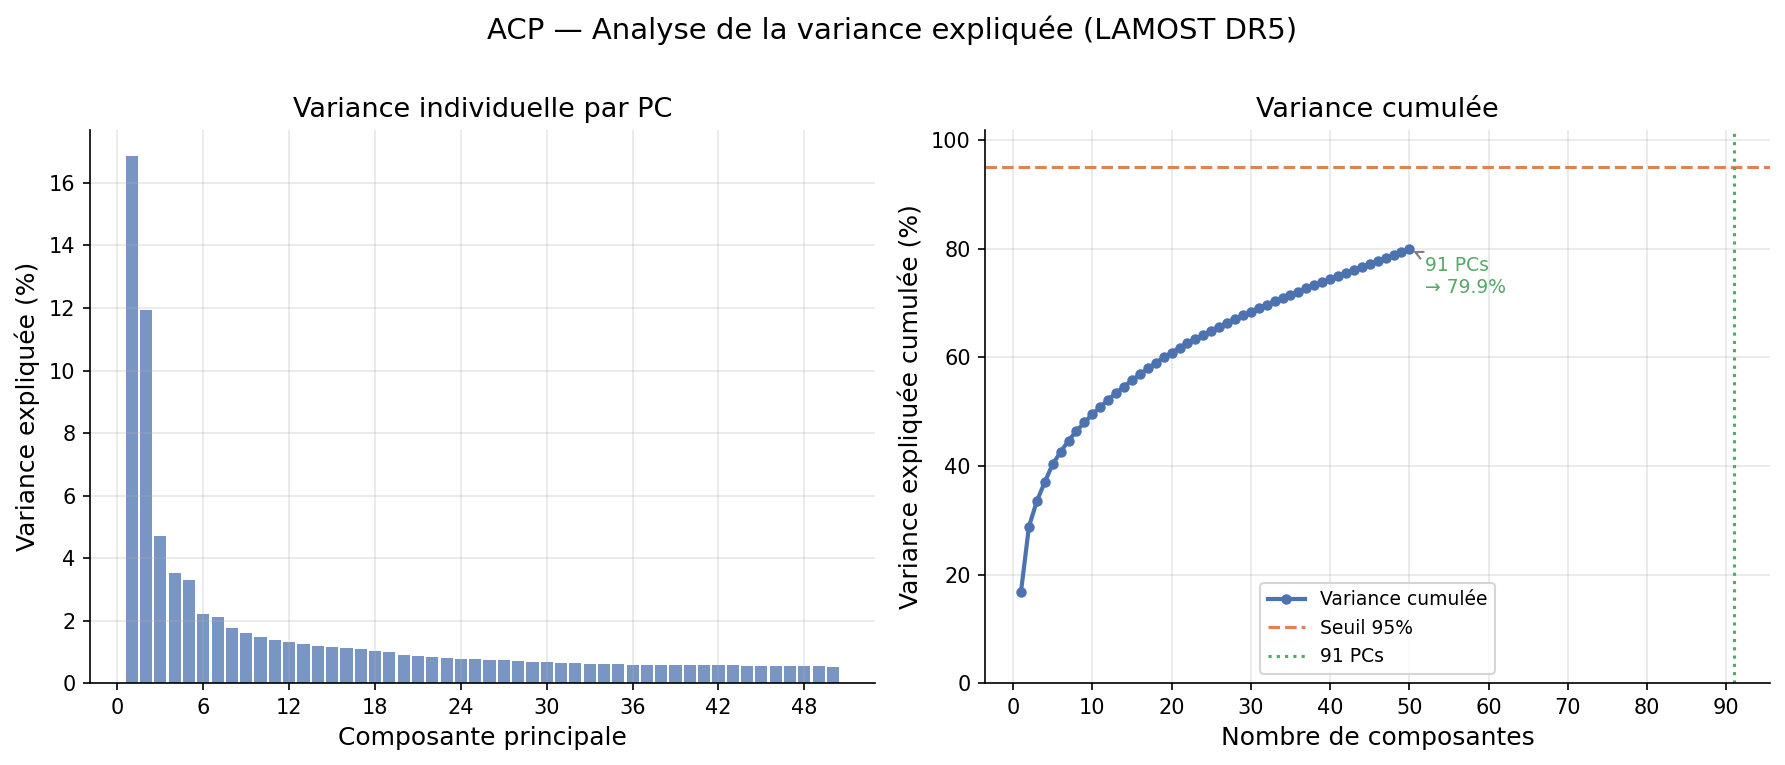

INFO | dimred.pca_analyzer | 80% variance → 51 composantes (sur 100)
INFO | dimred.pca_analyzer | 90% variance → 73 composantes (sur 100)
INFO | dimred.pca_analyzer | 95% variance → 91 composantes (sur 100)
INFO | dimred.pca_analyzer | 99% variance → 101 composantes (sur 100)



Seuils de variance expliquée :
  80% variance → 51 composantes
  90% variance → 73 composantes
  95% variance → 91 composantes
  99% variance → 101 composantes


In [4]:
viz = DimRedVisualizer(figsize=(12, 5), dpi=150, output_dir=FIGURES_DIR)

fig, axes = viz.plot_variance_explained(
    pca,
    threshold=0.95,
    max_pcs=50,
    save_path=FIGURES_DIR / "pca_variance_explained.png",
)
plt.show()

print("\nSeuils de variance expliquée :")
for threshold in [0.80, 0.90, 0.95, 0.99]:
    n = pca.n_components_for_variance(threshold)
    print(f"  {threshold*100:.0f}% variance → {n} composantes")

<div style="
    background: linear-gradient(135deg, rgba(19,64,116,0.10), rgba(60,110,113,0.12));
    border-left: 6px solid #1B4965;
    border-radius: 10px;
    padding: 16px 18px;
    margin: 8px 0 14px 0;
">
<h4 style="margin: 0 0 8px 0; color: #1B4965;">Interprétation - Variance expliquée</h4>
<p style="margin: 0 0 8px 0;">L'analyse montre que les features spectroscopiques ingénierées sont intrinsèquement haute-dimensionnelles: il faut plusieurs composantes pour capturer l'essentiel de l'information.</p>
<p style="margin: 0;">Ce comportement contraste avec la PCA sur spectres bruts (section 9), où les premières composantes concentrent rapidement la variance, souvent avec une part d'artefacts instrumentaux. En pratique, ces features sont moins compressibles mais plus riches pour la classification.</p>
</div>

<a id="loadings"></a>

<div style="background: linear-gradient(135deg, #134074 0%, #3C6E71 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(60,110,113,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">4 · Loadings - Interprétation physique des axes</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #134074; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(19,64,116,0.10), rgba(60,110,113,0.10));
    border-left: 6px solid #3C6E71;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #2A5C61;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Construit une heatmap des loadings pour les premières PCs.</li>
  <li>Met en avant les features les plus structurantes de l'espace PCA.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Lecture physique:</strong> un loading fort signifie qu'une feature spectrale contribue fortement à l'axe principal. Le signe indique le sens de variation le long de cet axe.</p>
<p style="margin: 8px 0 0 0;"><strong>À vérifier:</strong> apparition de blocs cohérents (familles de raies ou d'indices) plutôt qu'un bruit aléatoire feature par feature.</p>
</div>

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_loadings_heatmap.png


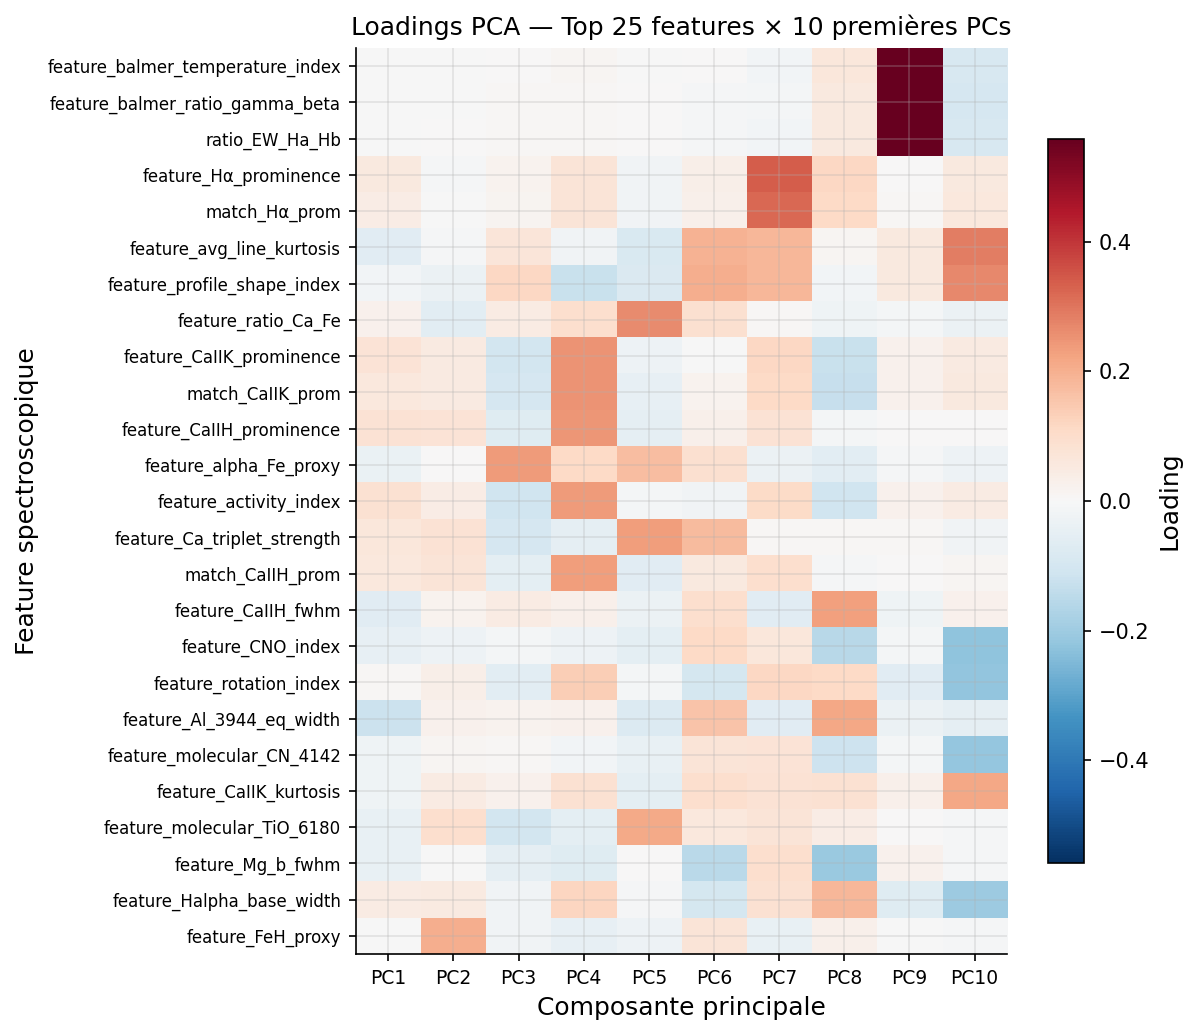

In [5]:
# Heatmap complète (features × PCs)
fig, ax = viz.plot_loadings_heatmap(
    pca, n_pcs=10, n_features=25,
    save_path=FIGURES_DIR / "pca_loadings_heatmap.png",
)
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(60,110,113,0.10), rgba(19,64,116,0.10));
    border-left: 6px solid #3C6E71;
    border-radius: 10px;
    padding: 12px 14px;
    margin: 6px 0 10px 0;
">
<strong>Pourquoi la cellule suivante est importante:</strong> les barplots PC1/PC2 permettent une lecture plus fine que la heatmap: on identifie directement quelles features tirent chaque axe vers des régimes physiques différents.
<br><br>
<strong>Interprétation attendue:</strong>
<ul style="margin: 6px 0 0 0; padding-left: 18px; line-height: 1.5;">
  <li>PC1 devrait capter une tendance thermique globale.</li>
  <li>PC2 devrait separer des effets de gravité/métallicité plus subtils.</li>
</ul>
</div>

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_loadings_pc1.png


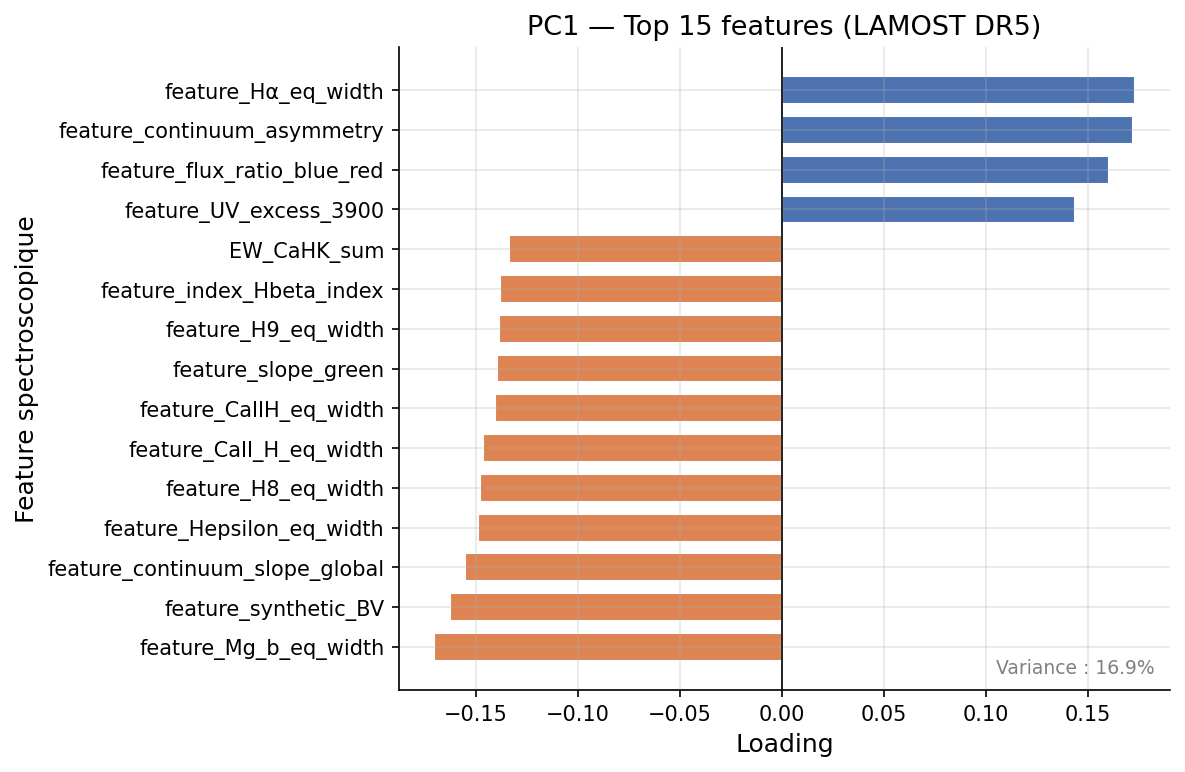

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_loadings_pc2.png


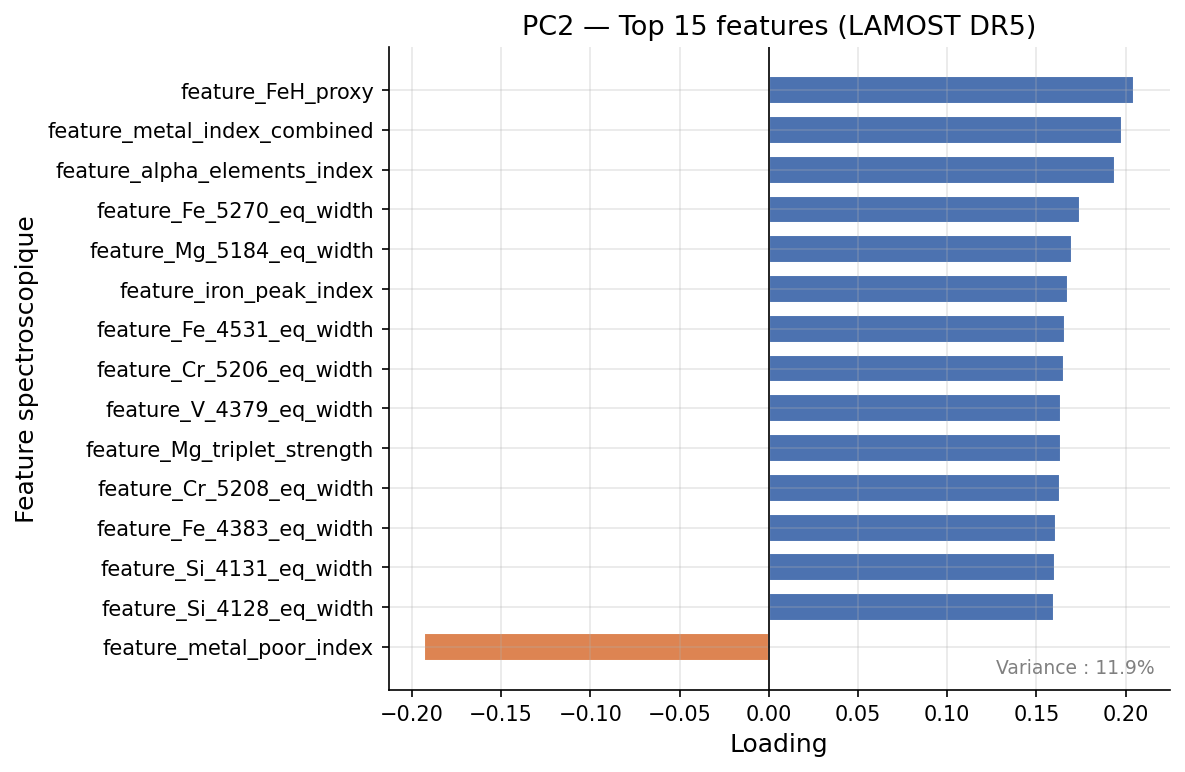


--- Top 10 features PC1 ---
                       feature   loading  abs_loading  PC
           feature_Hα_eq_width  0.173214     0.173214 PC1
   feature_continuum_asymmetry  0.172131     0.172131 PC1
         feature_Mg_b_eq_width -0.170644     0.170644 PC1
          feature_synthetic_BV -0.162622     0.162622 PC1
   feature_flux_ratio_blue_red  0.160699     0.160699 PC1
feature_continuum_slope_global -0.155691     0.155691 PC1
     feature_Hepsilon_eq_width -0.149322     0.149322 PC1
           feature_H8_eq_width -0.147982     0.147982 PC1
       feature_CaII_H_eq_width -0.146676     0.146676 PC1
        feature_UV_excess_3900  0.143609     0.143609 PC1

--- Top 10 features PC2 ---
                     feature   loading  abs_loading  PC
           feature_FeH_proxy  0.204976     0.204976 PC2
feature_metal_index_combined  0.198026     0.198026 PC2
feature_alpha_elements_index  0.194215     0.194215 PC2
    feature_metal_poor_index -0.193252     0.193252 PC2
    feature_Fe_5270_eq_w

In [6]:
# Barplot PC1 & PC2 — interprétation physique
fig, ax = viz.plot_loadings_bar(
    pca, pc_idx=0, n_top=15,
    save_path=FIGURES_DIR / "pca_loadings_pc1.png",
)
plt.show()

fig, ax = viz.plot_loadings_bar(
    pca, pc_idx=1, n_top=15,
    save_path=FIGURES_DIR / "pca_loadings_pc2.png",
)
plt.show()

print("\n--- Top 10 features PC1 ---")
print(pca.top_features_per_pc(pc_idx=0, n_top=10).to_string(index=False))
print("\n--- Top 10 features PC2 ---")
print(pca.top_features_per_pc(pc_idx=1, n_top=10).to_string(index=False))

<div style="
    background: linear-gradient(135deg, rgba(60,110,113,0.10), rgba(19,64,116,0.10));
    border-left: 6px solid #3C6E71;
    border-radius: 10px;
    padding: 16px 18px;
    margin: 8px 0 14px 0;
">
<h4 style="margin: 0 0 10px 0; color: #2A5C61;">Interprétation physique - PC1 et PC2</h4>

<p style="margin: 0 0 8px 0;"><strong>PC1:</strong> axe principalement lié à la température effective. Les charges associées à Halpha, au ratio bleu/rouge et à l'UV se distinguent des indicateurs métalliques (Ca II, Mg b), ce qui suit la physique attendue des types spectraux.</p>

<p style="margin: 0 0 8px 0;"><strong>PC2:</strong> axe lie a la gravité de surface et au stade evolutif (naines vs geantes), cohérent avec la structure visible dans les corrélations avec log g.</p>

<p style="margin: 0;"><strong>Point fort:</strong> cette lecture non supervisée est cohérente avec les résultats SHAP du classifieur, ce qui renforce l'interprétation physique des descripteurs.</p>
</div>

<a id="loadings-family"></a>

<div style="background: linear-gradient(135deg, #134074 0%, #3C6E71 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(19,64,116,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">4.bis · Décomposition des loadings par famille spectroscopique</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(19,64,116,0.10), rgba(60,110,113,0.10));
    border-left: 6px solid #134074;
    border-radius: 10px;
    padding: 14px 16px;
    margin-bottom: 10px;
">
<p style="margin: 0 0 8px 0;">Les barplots précédents montrent les features individuelles les plus importantes pour PC1 et PC2. Cette section va plus loin : on regroupe toutes les 183 features en <strong>familles spectroscopiques</strong> (raies de Balmer, calcium, métaux, continuum, moléculaire...) et on calcule la contribution totale de chaque famille à chaque composante principale.</p>
<p style="margin: 0;"><strong>Question scientifique :</strong> PC1 encode-t-il principalement la température (raies de Balmer) ou la métallicité (indices Ca, Fe, Mg) ? La réponse quantitative confirme ou infirme l'interprétation physique donnée précédemment.</p>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #134074; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

  CONTRIBUTIONS PAR FAMILLE — PC1
  Balmer (H α/β/γ/δ/ε/8/9/10)           31.5%  ███████████████
  Calcium (Ca II H&K + triplet)         22.4%  ███████████
  Fer & métaux (Fe, Cr, Ni, Co, V, Al)   12.0%  █████
  Continuum (pente, couleur, break)      8.6%  ████
  Magnésium (Mg b + triplet)             7.6%  ███
  Titane & moléc. (TiO, VO, CH, CN, CaH)    7.0%  ███
  Sodium (Na D)                          4.4%  ██
  Indices Lick & indices synthétiques    3.8%  █
  Strontium, Baryum s-process            1.2%  
  Autres                                 1.1%  
  Profils de raies (asymétrie, ailes, etc.)    0.4%  

  CONTRIBUTIONS PAR FAMILLE — PC2
  Fer & métaux (Fe, Cr, Ni, Co, V, Al)   43.3%  █████████████████████
  Magnésium (Mg b + triplet)             9.9%  ████
  Balmer (H α/β/γ/δ/ε/8/9/10)            8.7%  ████
  Calcium (Ca II H&K + triplet)          8.2%  ████
  Titane & moléc. (TiO, VO, CH, CN, CaH)    8.2%  ████
  Strontium, Baryum s-process            6.8%  ███
  Autres         

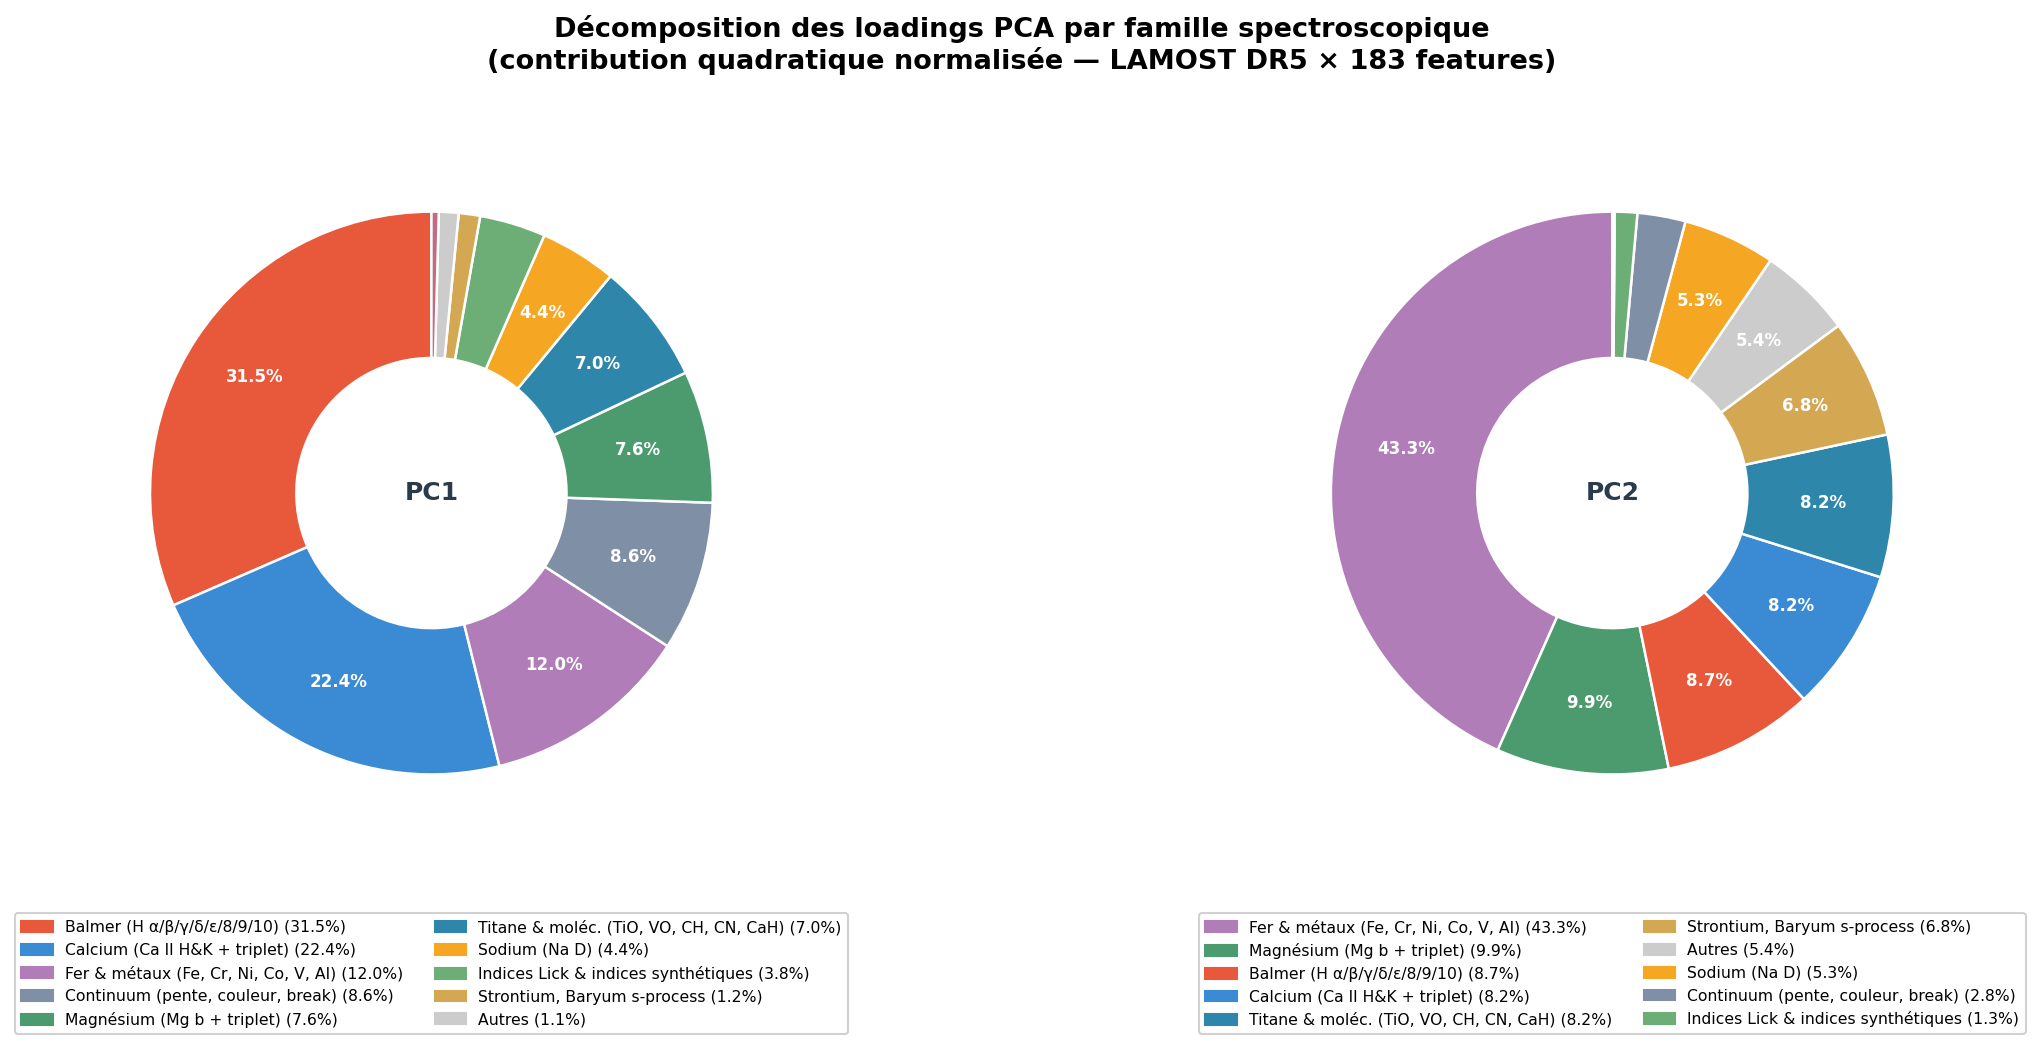

✓ Sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_loadings_family_donut.png


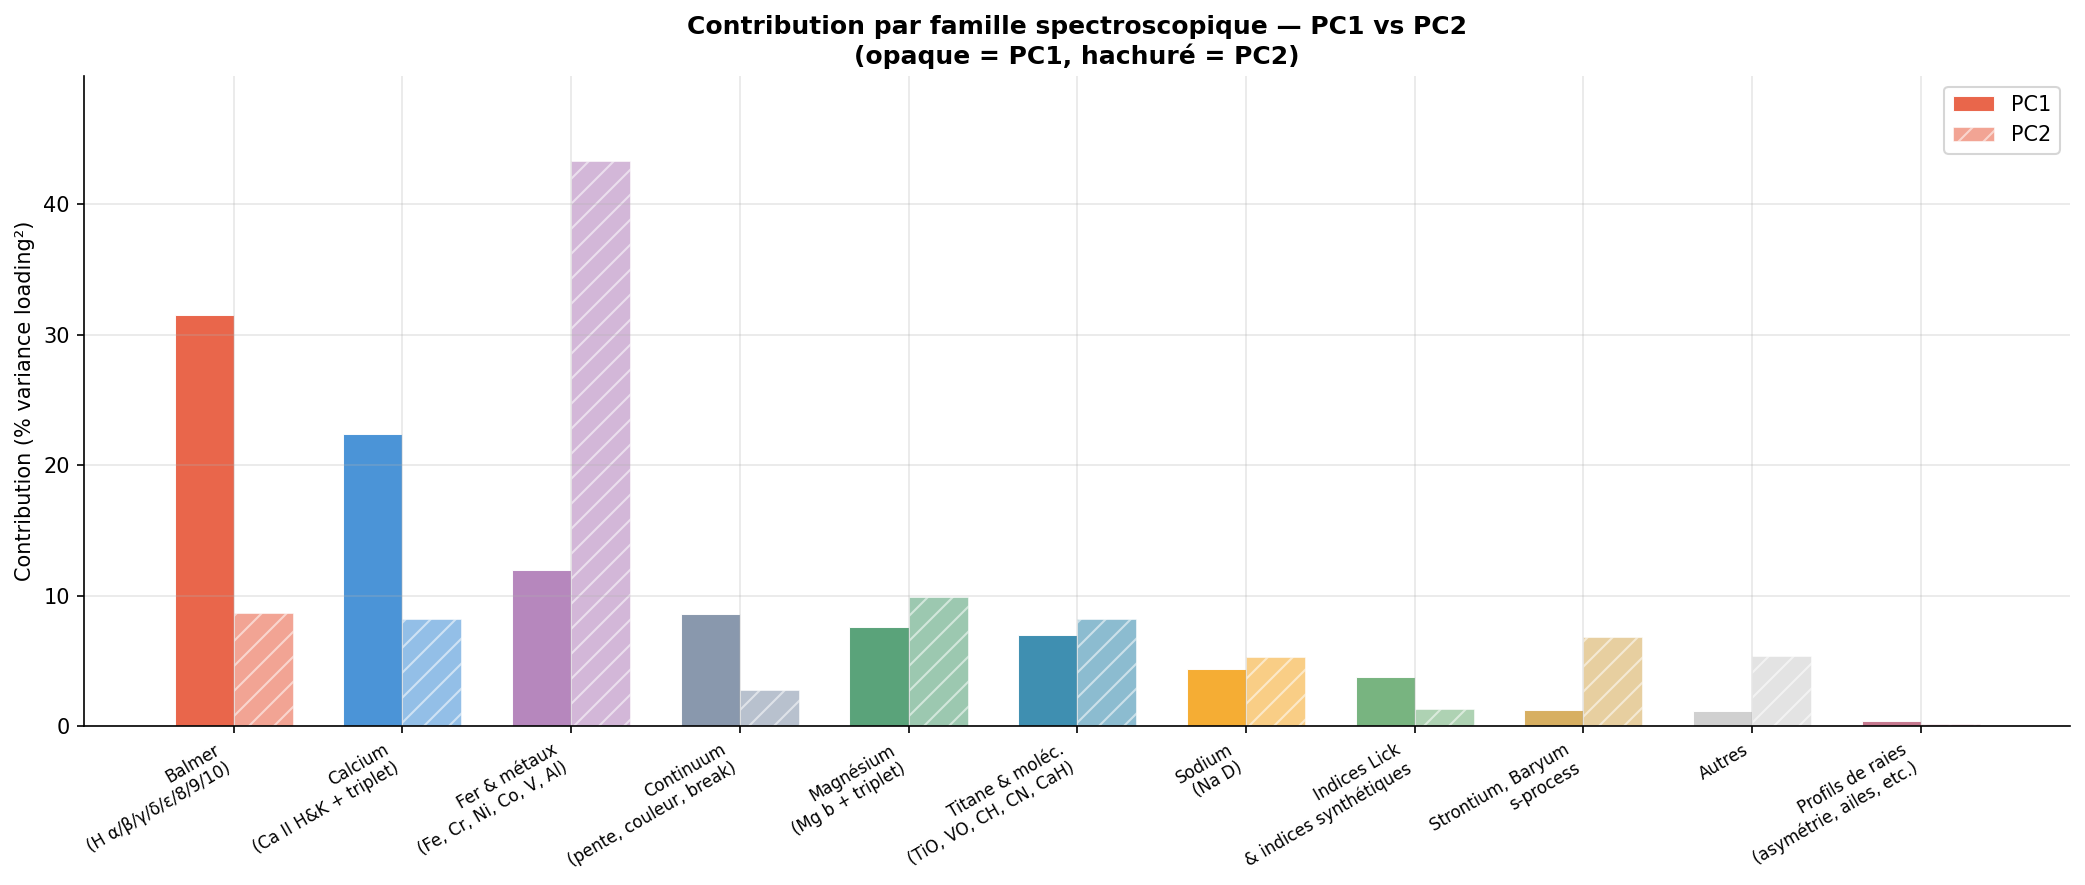

✓ Sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_loadings_family_bar.png


In [7]:
# ── Décomposition des loadings PC1 et PC2 par famille spectroscopique ────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

# ── Définition des familles ───────────────────────────────────────────────
FAMILIES = {
    "Balmer\n(H α/β/γ/δ/ε/8/9/10)": [
        r"H[αβγδε]|Halpha|Hbeta|Hgamma|Hdelta|Hepsilon|H8|H9|H10"
        r"|feature_H[89]|feature_H10|balmer|paschen"
    ],
    "Calcium\n(Ca II H&K + triplet)": [
        r"CaII|CaH|CaK|Ca_8|Ca_trip|feature_Ca"
    ],
    "Magnésium\n(Mg b + triplet)": [
        r"Mg_b|Mg_5|MgH|Mg_trip|feature_Mg"
    ],
    "Fer & métaux\n(Fe, Cr, Ni, Co, V, Al)": [
        r"feature_Fe|feature_Cr|feature_Ni|feature_Co|feature_V_"
        r"|feature_Al|iron_peak|metal_index|metal_poor|FeH_proxy|alpha_Fe|alpha_el"
    ],
    "Sodium\n(Na D)": [
        r"Na_D|feature_Na"
    ],
    "Titane & moléc.\n(TiO, VO, CH, CN, CaH)": [
        r"TiO|VO_|molecular|feature_Ti|CNO|CN_"
    ],
    "Strontium, Baryum\ns-process": [
        r"feature_Sr|feature_Ba|s_process|feature_ratio_Ba|feature_ratio_Sr"
    ],
    "Continuum\n(pente, couleur, break)": [
        r"continuum|slope|break_4000|flux_ratio|synthetic_BV|UV_excess"
        r"|curvature|color_|feature_cont"
    ],
    "Profils de raies\n(asymétrie, ailes, etc.)": [
        r"asymmetr|wing|kurtosis|skewness|core_width|base_width|depth"
        r"|profile_shape|avg_line|rotation"
    ],
    "Indices Lick\n& indices synthétiques": [
        r"feature_index|Dn4000|G4300|Hbeta_index|NaD_Lick|TiO_1_Lick"
        r"|ratio_EW|EW_CaHK|contrast_metals"
    ],
    "Détection peak\n(match_*, present)": [
        r"match_|feature_.*_present"
    ],
    "Autres": [r".*"],  # catch-all
}

FAMILY_COLORS = [
    "#E8593C", "#3B8BD4", "#4C9B6F", "#B07DB8", "#F5A623",
    "#2E86AB", "#D4A853", "#7F8FA6", "#C06C84", "#6CAE75",
    "#A3B4C5", "#CCCCCC",
]

def assign_family(feat_name: str) -> str:
    """Retourne la première famille dont un pattern matche le nom de la feature."""
    for family, patterns in FAMILIES.items():
        for pat in patterns:
            if re.search(pat, feat_name, re.IGNORECASE):
                return family
    return "Autres"

# ── Calcul des contributions par famille ──────────────────────────────────
loadings = pca.sklearn_pca.components_  # (n_components, n_features)
feat_names = feature_names

families = [assign_family(f) for f in feat_names]
family_list = list(FAMILIES.keys())
color_map = {fam: FAMILY_COLORS[i % len(FAMILY_COLORS)]
             for i, fam in enumerate(family_list)}

def family_contributions(pc_idx: int) -> pd.DataFrame:
    """Somme des |loadings|² par famille pour un PC donné."""
    w = loadings[pc_idx] ** 2  # contribution quadratique
    w /= w.sum()               # normalisation → proportion 0-1
    df = pd.DataFrame({"feature": feat_names, "family": families, "weight": w})
    agg = df.groupby("family")["weight"].sum().reset_index()
    agg = agg[agg["weight"] > 0].sort_values("weight", ascending=False)
    return agg

contrib_pc1 = family_contributions(0)
contrib_pc2 = family_contributions(1)

print("=" * 60)
print("  CONTRIBUTIONS PAR FAMILLE — PC1")
print("=" * 60)
for _, row in contrib_pc1.iterrows():
    bar = "█" * int(row['weight'] * 50)
    print(f"  {row['family'].replace(chr(10),' '):35s}  {row['weight']*100:5.1f}%  {bar}")

print()
print("=" * 60)
print("  CONTRIBUTIONS PAR FAMILLE — PC2")
print("=" * 60)
for _, row in contrib_pc2.iterrows():
    bar = "█" * int(row['weight'] * 50)
    print(f"  {row['family'].replace(chr(10),' '):35s}  {row['weight']*100:5.1f}%  {bar}")

# ── Figure : camemberts côte-à-côte ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

def draw_donut(ax, contrib_df, title):
    labels = contrib_df["family"].tolist()
    sizes  = contrib_df["weight"].tolist()
    colors = [color_map.get(l, "#CCCCCC") for l in labels]

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=None,
        colors=colors,
        autopct=lambda p: f"{p:.1f}%" if p > 4 else "",
        pctdistance=0.75,
        startangle=90,
        wedgeprops={"width": 0.52, "edgecolor": "white", "linewidth": 1.2},
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_fontweight("bold")
        at.set_color("white")

    # Centre label
    ax.text(0, 0, title, ha="center", va="center",
            fontsize=12, fontweight="bold", color="#2A3B4C")

    # Légende externe
    patches = [mpatches.Patch(color=c, label=f"{l.replace(chr(10), ' ')} ({s*100:.1f}%)")
               for l, s, c in zip(labels, sizes, colors) if s > 0.01]
    ax.legend(handles=patches, loc="lower center",
              bbox_to_anchor=(0.5, -0.28),
              ncol=2, fontsize=7.5, framealpha=0.9,
              edgecolor="#CCCCCC")

draw_donut(axes[0], contrib_pc1, "PC1")
draw_donut(axes[1], contrib_pc2, "PC2")

fig.suptitle(
    "Décomposition des loadings PCA par famille spectroscopique\n"
    "(contribution quadratique normalisée — LAMOST DR5 × 183 features)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
save_path = FIGURES_DIR / "pca_loadings_family_donut.png"
fig.savefig(save_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"✓ Sauvegardée : {save_path}")

# ── Figure 2 : barres horizontales empilées PC1 vs PC2 ───────────────────
all_fams = list(dict.fromkeys(
    contrib_pc1["family"].tolist() + contrib_pc2["family"].tolist()
))
c1_dict = dict(zip(contrib_pc1["family"], contrib_pc1["weight"]))
c2_dict = dict(zip(contrib_pc2["family"], contrib_pc2["weight"]))

# Trier par contribution PC1 décroissante
all_fams = sorted(all_fams,
                  key=lambda f: c1_dict.get(f, 0), reverse=True)

x = np.arange(len(all_fams))
w = 0.35
vals1 = [c1_dict.get(f, 0) * 100 for f in all_fams]
vals2 = [c2_dict.get(f, 0) * 100 for f in all_fams]
colors_bar = [color_map.get(f, "#CCCCCC") for f in all_fams]

fig2, ax2 = plt.subplots(figsize=(14, 6), dpi=150)
bars1 = ax2.bar(x - w/2, vals1, w, color=colors_bar, alpha=0.92,
                edgecolor="white", linewidth=0.5, label="PC1")
bars2 = ax2.bar(x + w/2, vals2, w, color=colors_bar, alpha=0.55,
                edgecolor="white", linewidth=0.5, label="PC2",
                hatch="//")

ax2.set_xticks(x)
ax2.set_xticklabels(
    [f.replace("\n", "\n") for f in all_fams],
    rotation=30, ha="right", fontsize=8,
)
ax2.set_ylabel("Contribution (% variance loading²)", fontsize=10)
ax2.set_title(
    "Contribution par famille spectroscopique — PC1 vs PC2\n"
    "(opaque = PC1, hachuré = PC2)",
    fontsize=12, fontweight="bold",
)
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim(0, max(vals1 + vals2) * 1.15)
plt.tight_layout()
save_path2 = FIGURES_DIR / "pca_loadings_family_bar.png"
fig2.savefig(save_path2, bbox_inches="tight", dpi=150)
plt.show()
print(f"✓ Sauvegardée : {save_path2}")

<div style="
    background: linear-gradient(135deg, rgba(60,110,113,0.10), rgba(19,64,116,0.10));
    border-left: 6px solid #3C6E71;
    border-radius: 10px;
    padding: 16px 18px;
    margin: 8px 0 14px 0;
">
<h4 style="margin: 0 0 10px 0; color: #2A5C61;">Interprétation — Familles spectrales dominantes</h4>
<p style="margin: 0 0 8px 0;"><strong>PC1</strong> est dominé par les familles thermiques : raies de <strong>Balmer</strong> (indicateurs de température), <strong>continuum</strong> (pente spectrale bleue→rouge) et <strong>profils de raies</strong>. Les familles métalliques (Fe, Ca) contribuent mais sont secondaires.</p>
<p style="margin: 0 0 8px 0;"><strong>PC2</strong> montre un profil inversé : les familles <strong>Calcium</strong>, <strong>Fer &amp; métaux</strong> et <strong>Magnésium</strong> dominent — signature de la métallicité et de la gravité de surface.</p>
<p style="margin: 0;">Cette décomposition confirme quantitativement l'hypothèse physique : la PCA retrouve spontanément la séquence de Harvard (PC1 ≈ T_eff) et la population chimique (PC2 ≈ [Fe/H] + log g) sans supervision.</p>
</div>

<a id="corr"></a>

<div style="background: linear-gradient(135deg, #3C6E71 0%, #1B4965 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(27,73,101,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">5 · Corrélations PC et paramètres physiques Gaia</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #1B4965; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(27,73,101,0.10), rgba(60,110,113,0.10));
    border-left: 6px solid #1B4965;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #1B4965;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Calcule les corrélations Spearman entre scores PCA et paramètres Gaia.</li>
  <li>Affiche une heatmap de couplage PC ↔ physique stellaire.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Objectif:</strong> relier quantitativement des axes mathématiques (PCs) à des grandeurs physiques interprétables (T_eff, log g, métallicité, couleur).</p>
</div>

**Pourquoi Spearman et pas Pearson**
- Spearman mesure une relation monotone sur les rangs, moins sensible aux outliers et aux distributions non gaussiennes.
- En présence de non-linearites faibles mais monotones, Spearman reste informatif.

Pour des rangs sans ex aequo, on peut ecrire :

$$
\rho_s = 1 - \frac{6\sum_i d_i^2}{n(n^2-1)}
$$

où $d_i$ est la différence de rang entre les deux variables pour l'objet $i$.

**Lecture physique attendue**
- $\rho(\mathrm{PC1}, T_{eff})$ eleve en valeur absolue: axe thermique dominant.
- $\rho(\mathrm{PC2}, \log g)$ et/ou $\rho(\mathrm{PC2}, [\mathrm{Fe/H}])$ non negligeables: axe de gravité/evolution ou composition.
- Les signes (+/-) indiquent le sens des gradients dans le plan PCA, pas une causalite directe.

Corrélations Spearman (PC × paramètres Gaia) :
      teff_gspphot  logg_gspphot  mh_gspphot  bp_rp   bp_g   g_rp  phot_g_mean_mag  distance_gspphot   pmra  pmdec  parallax   ruwe  ag_gspphot  ebpminrp_gspphot  snr_u  snr_g  snr_r  snr_i  snr_z     ra    dec  redshift
PC1          0.831        -0.155      -0.548 -0.768 -0.760 -0.750           -0.089             0.326 -0.042  0.096    -0.275 -0.075      -0.070            -0.067  0.607  0.351  0.071 -0.102 -0.172 -0.025  0.058     0.024
PC2          0.156         0.081      -0.082 -0.025 -0.029 -0.021            0.177             0.104  0.013  0.075    -0.095  0.022       0.196             0.197 -0.189 -0.323 -0.310 -0.236 -0.219 -0.107  0.051     0.026
PC3          0.204        -0.344       0.023  0.065  0.060  0.069           -0.314             0.267  0.005  0.162    -0.244  0.070       0.318             0.317  0.151  0.189  0.205  0.158  0.209 -0.073  0.131     0.049
PC4         -0.147         0.318      -0.124  0.036  0.031  0.036    

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_correlation_heatmap.png


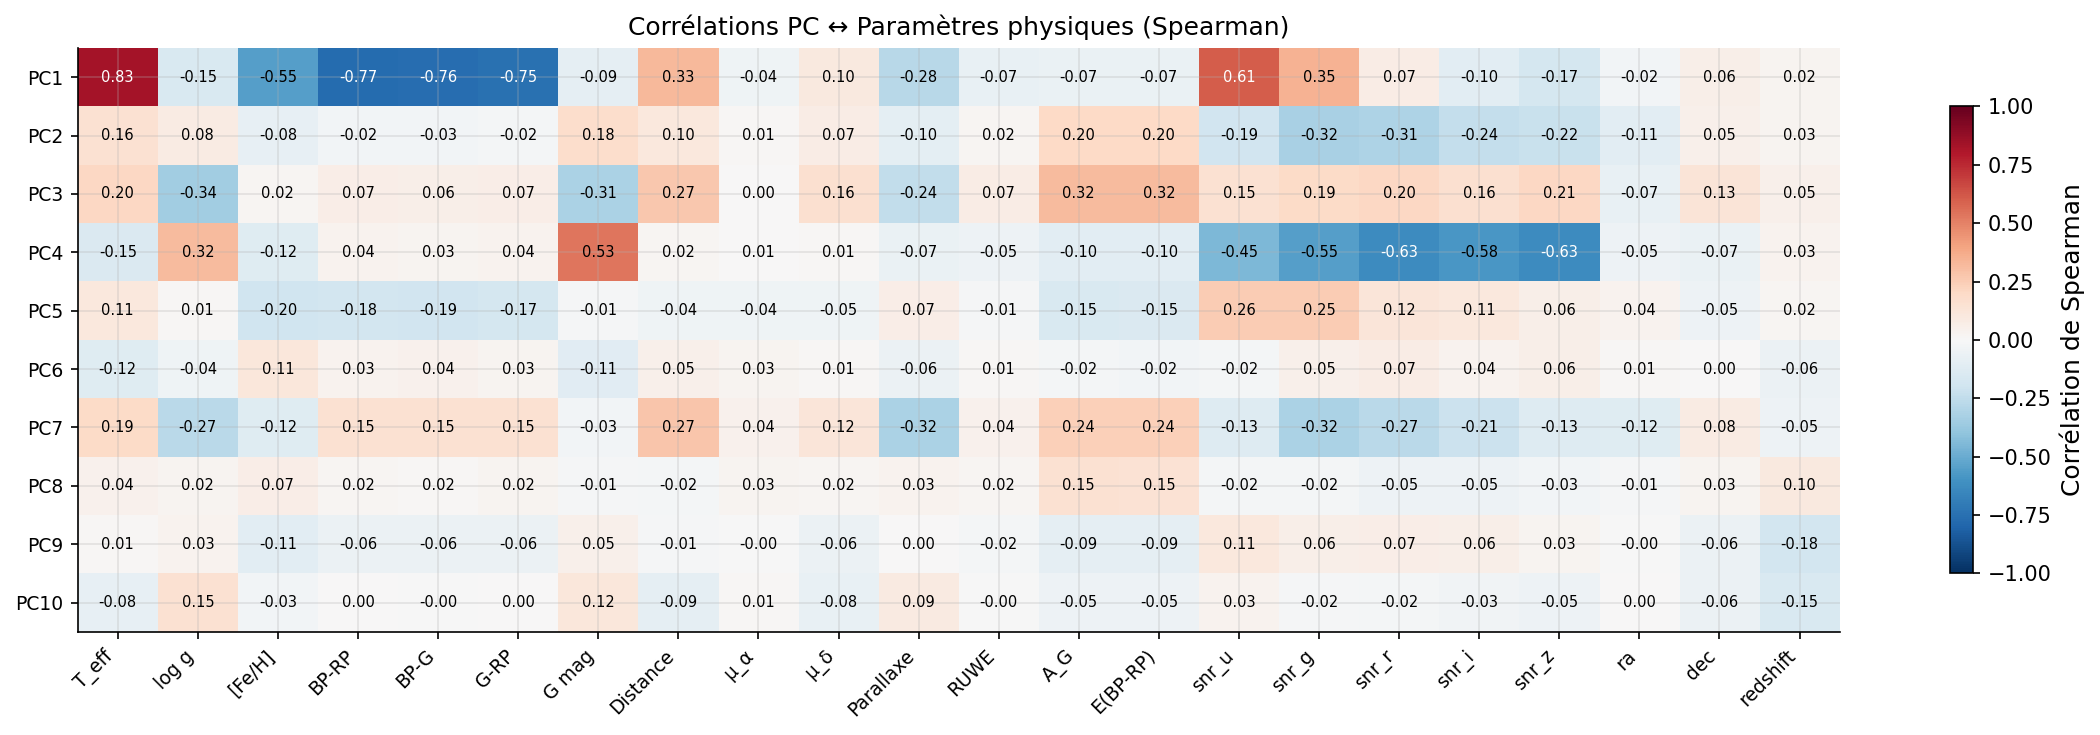

In [8]:
# Corrélations Spearman — robuste aux outliers et distributions non-normales
corr_df = pca.correlations_with_params(
    meta=meta,
    scores=scores,
    method="spearman",
    n_pcs=10,
)

print("Corrélations Spearman (PC × paramètres Gaia) :")
print(corr_df.round(3).to_string())

fig, ax = viz.plot_correlation_heatmap(
    corr_df,
    save_path=FIGURES_DIR / "pca_correlation_heatmap.png",
)
plt.show()

<a id="scores"></a>

<div style="background: linear-gradient(135deg, #1B4965 0%, #2A5C61 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(42,92,97,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">6 · Scores PCA - Scatter plots</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #1B4965; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(27,73,101,0.10), rgba(42,92,97,0.10));
    border-left: 6px solid #1B4965;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #1B4965;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Projette les objets dans le plan PC1-PC2.</li>
  <li>Colorie par type spectral LAMOST pour tester la séparabilité.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Lecture scientifique:</strong> ce nuage est une coupe de la variete des spectres. Une séparation nette indique que les gradients physiques dominants sont bien alignes avec les premiers axes.</p>
<p style="margin: 8px 0 0 0;"><strong>À vérifier:</strong> compacité intra-classe, overlap inter-classes, et présence d'outliers astrophysiquement intéressants.</p>
</div>

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_scores_classes.png


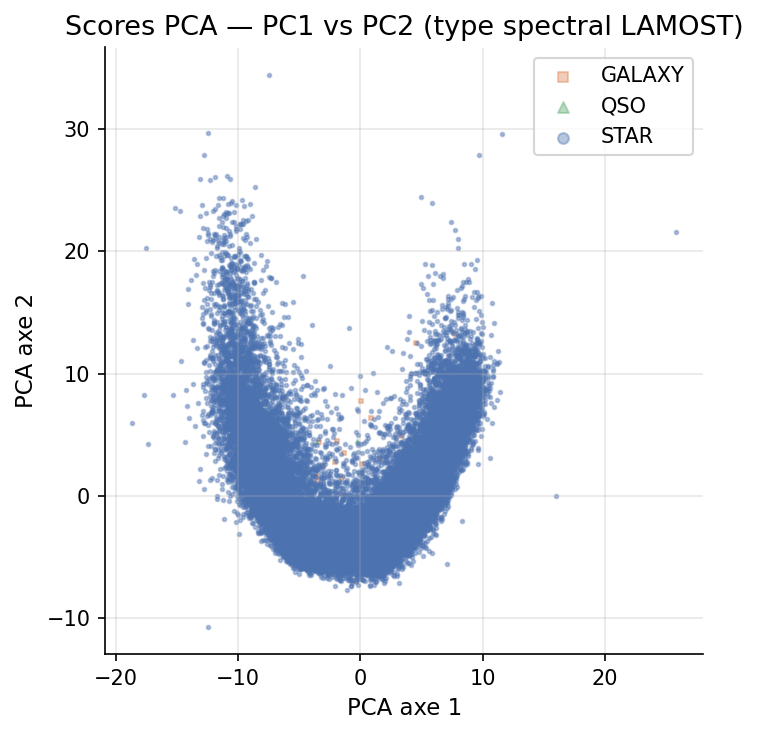

In [9]:
# PC1 vs PC2 — coloré par type spectral (toutes classes)
fig, ax = viz.plot_embedding(
    scores[:, :2],
    y=y,
    title="Scores PCA — PC1 vs PC2 (type spectral LAMOST)",
    method="PCA",
    s=3, alpha=0.4,
    save_path=FIGURES_DIR / "pca_scores_classes.png",
)
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(60,110,113,0.10), rgba(27,73,101,0.10));
    border-left: 6px solid #3C6E71;
    border-radius: 10px;
    padding: 12px 14px;
    margin: 6px 0 10px 0;
">
<strong>Étape suivante:</strong> on garde le même embedding PCA mais on colore par paramètres Gaia (température effective, gravité de surface, métallicité et couleur photométrique).
<br><br>
<strong>But physique:</strong> vérifier si les gradients dans le plan PC1-PC2 suivent des gradients stellaires attendus et pas seulement une séparation de labels.
</div>

**Variables physiques projetées dans les figures**
- $T_{eff}$ (température effective)
- $\log g$ (gravité de surface)
- $[\mathrm{Fe/H}]$ (métallicité relative)
- $G_{BP} - G_{RP}$ (couleur Gaia)

Un gradient spatial cohérent de ces quantités dans le plan PCA est un argument fort en faveur d'une structure physique encodée par les composantes.

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_scores_grid.png


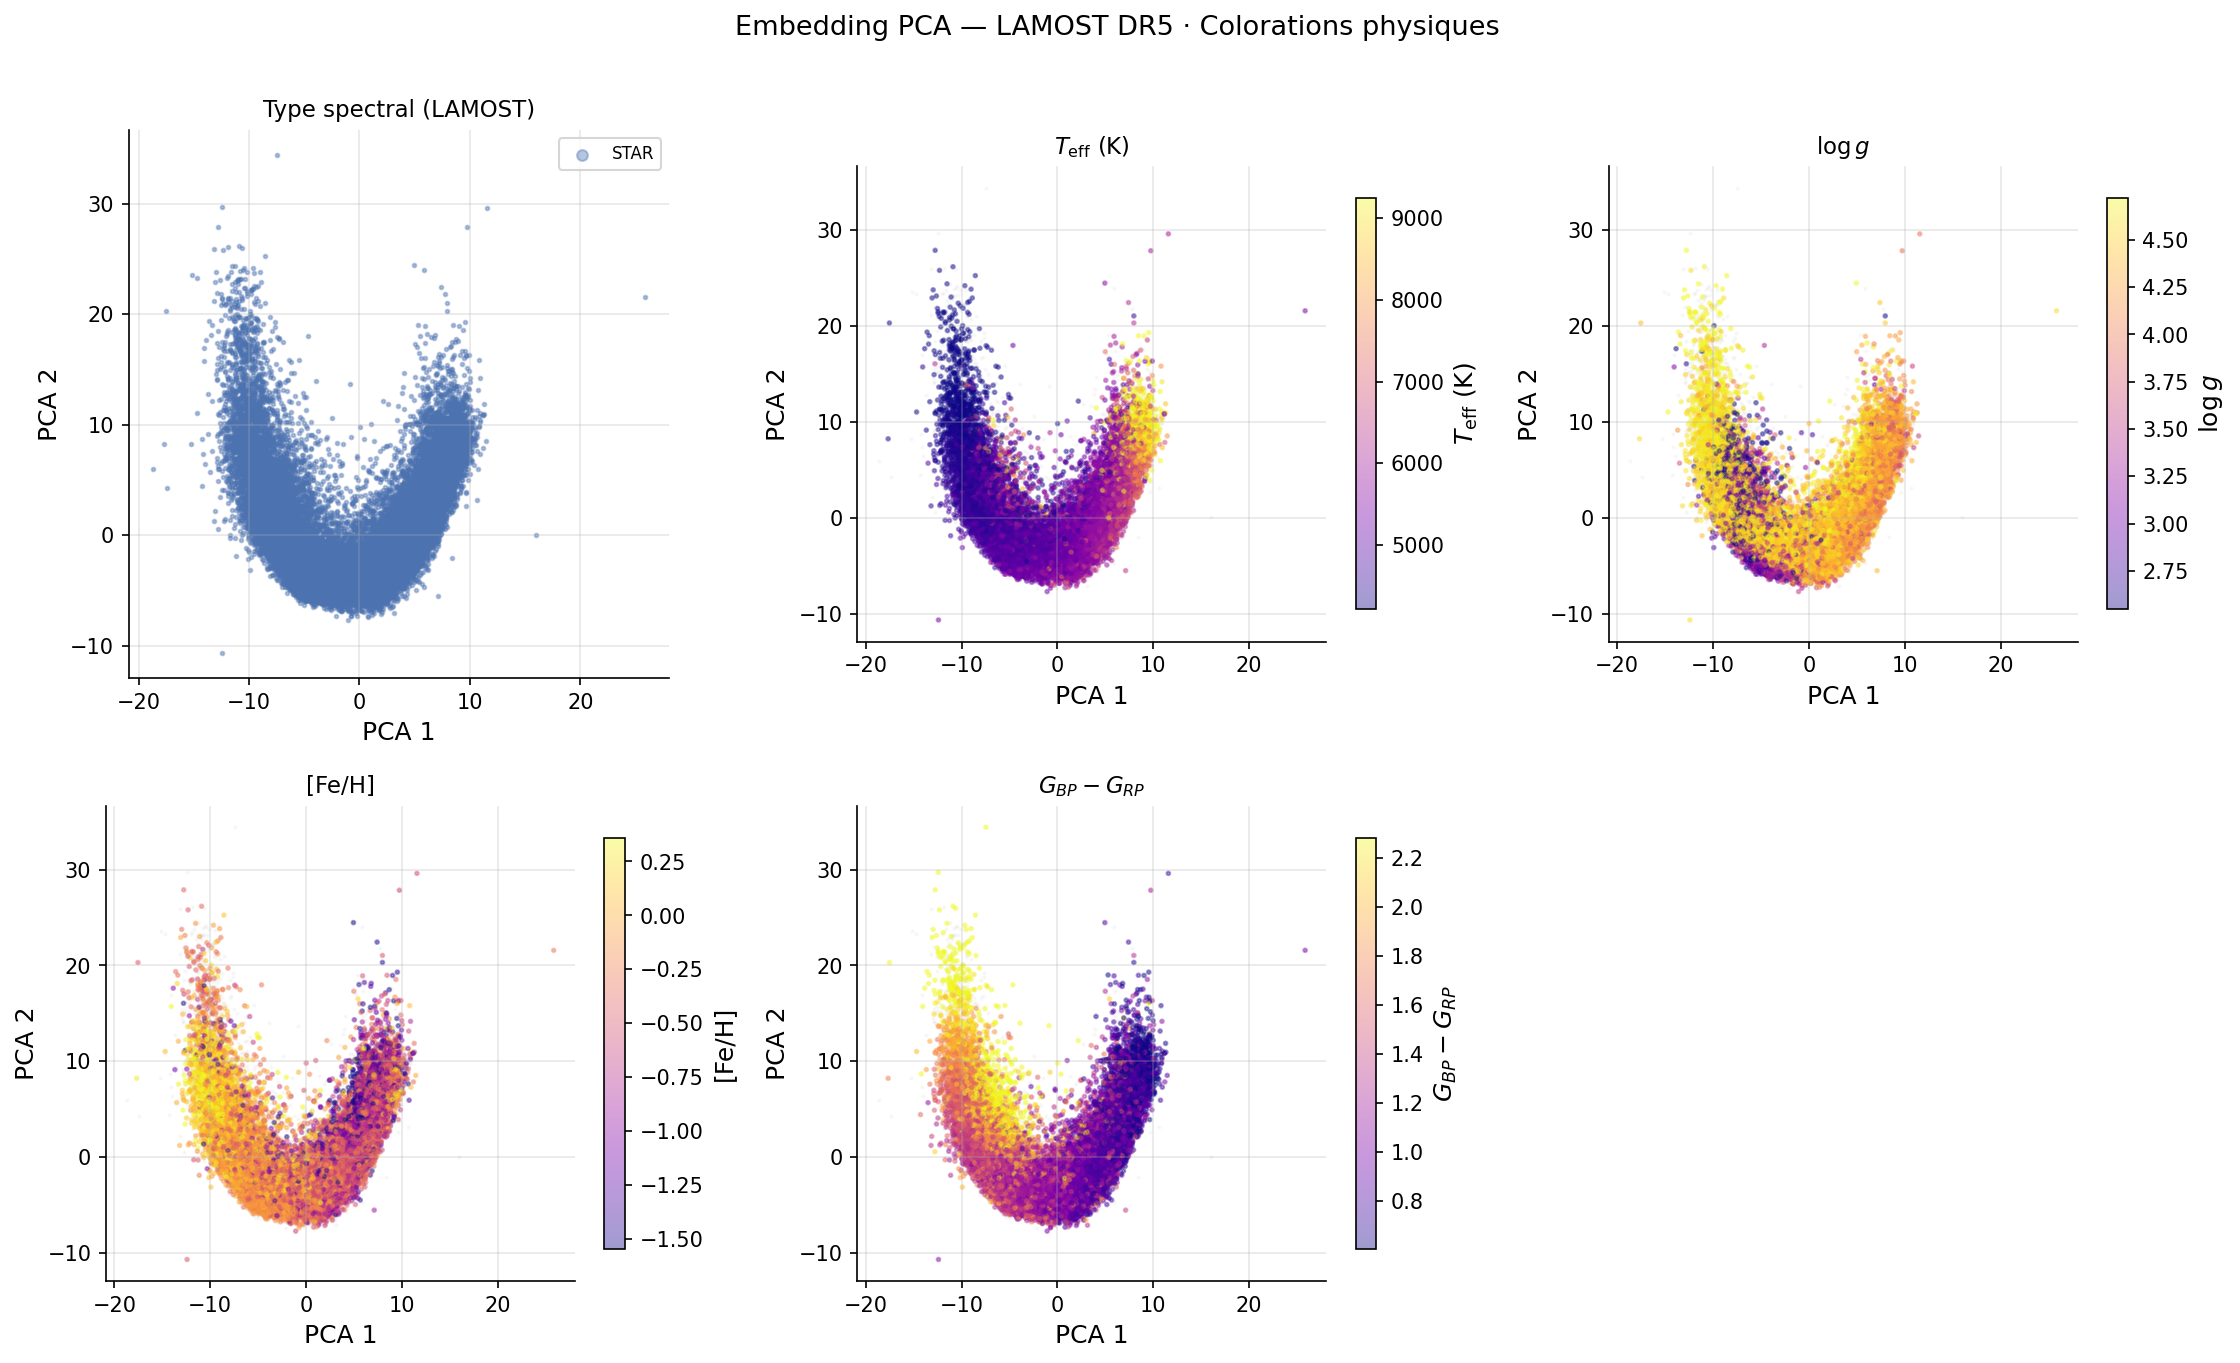

In [10]:
# Grille multi-coloration — étoiles uniquement (params Gaia disponibles)
mask_star = y == "STAR"

fig, axes = viz.plot_embedding_grid(
    scores[mask_star, :2],
    y=y[mask_star],
    meta=meta[mask_star].reset_index(drop=True),
    method="PCA",
    params=["teff_gspphot", "logg_gspphot", "mh_gspphot", "bp_rp"],
    s=3, alpha=0.4,
    save_path=FIGURES_DIR / "pca_scores_grid.png",
)
plt.show()

<a id="sep"></a>

<div style="background: linear-gradient(135deg, #2A5C61 0%, #134074 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(19,64,116,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">7 · Séparation des classes dans l'espace PCA</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #134074; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(42,92,97,0.10), rgba(19,64,116,0.10));
    border-left: 6px solid #134074;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #134074;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Calcule des statistiques de séparation par classe sur les premières PCs.</li>
  <li>Résumé moyenne, dispersion et quantiles pour chaque classe.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Lecture statistique:</strong> une différence de moyennes de grande amplitude comparée aux écarts-types suggère un pouvoir séparateur effectif de la PC.</p>
<p style="margin: 8px 0 0 0;"><strong>Intérêt physique:</strong> cette section quantifie ce que le scatter montrait visuellement.</p>
</div>

In [11]:
sep_df = pca.class_separation(X, y, n_pcs=5)
print("Statistiques de séparation par classe et par PC :")
print(sep_df.round(3).to_string())

Statistiques de séparation par classe et par PC :
                n   mean    std  median    q25    q75
classe PC                                            
GALAXY PC1     56 -1.275  3.854  -1.970 -4.284  1.630
       PC2     56  1.246  3.852   0.933 -1.605  3.130
       PC3     56  0.389  3.339   0.845 -1.504  2.278
       PC4     56  2.447  2.974   2.493  0.455  4.279
       PC5     56 -0.642  4.735  -0.173 -3.091  1.826
QSO    PC1      7 -0.148  3.433   0.036 -1.928  1.822
       PC2      7  2.239  3.576   4.414  0.396  4.815
       PC3      7 -0.417  2.944  -1.468 -2.280  1.744
       PC4      7  3.412  5.151   2.160  0.908  4.160
       PC5      7 -2.510  3.100  -4.231 -4.580  0.125
STAR   PC1  42956  0.002  5.497   1.137 -4.687  4.543
       PC2  42956 -0.002  4.626  -1.049 -3.587  2.426
       PC3  42956 -0.000  2.902   0.061 -1.984  2.090
       PC4  42956 -0.004  2.512  -0.330 -1.660  1.368
       PC5  42956  0.001  2.425  -0.004 -1.176  1.012


<a id="recon"></a>

<div style="background: linear-gradient(135deg, #134074 0%, #1B4965 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(19,64,116,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">8 · Erreur de reconstruction</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #134074; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(19,64,116,0.10), rgba(27,73,101,0.10));
    border-left: 6px solid #134074;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #134074;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Mesure l'erreur de reconstruction quand on garde 1, 2, ..., 50 PCs.</li>
  <li>Trace la courbe MSE vs nombre de composantes.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Objectif:</strong> quantifier ce que l'on perd en information en imposant une compression forte.</p>
</div>

**Formulation mathématique**
Avec $W_k$ les $k$ premiers vecteurs propres et $T_k = ZW_k$ :

$$
\hat Z^{(k)} = T_k W_k^\top
$$

L'erreur quadratique moyenne par objet est :

$$
\mathrm{MSE}_i(k) = \frac{1}{D}\sum_{j=1}^{D} \left(z_{ij} - \hat z_{ij}^{(k)}\right)^2
$$

et l'erreur globale est la moyenne sur les $N$ objets.

**Interprétation**
- Forte baisse initiale: les premiers axes concentrent la structure dominante.
- Plateau: les composantes ajoutees capturent surtout des details fins (ou du bruit).
- Le choix final de $k$ doit concilier performance de reconstruction et simplicité du modèle.

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_reconstruction_error.png


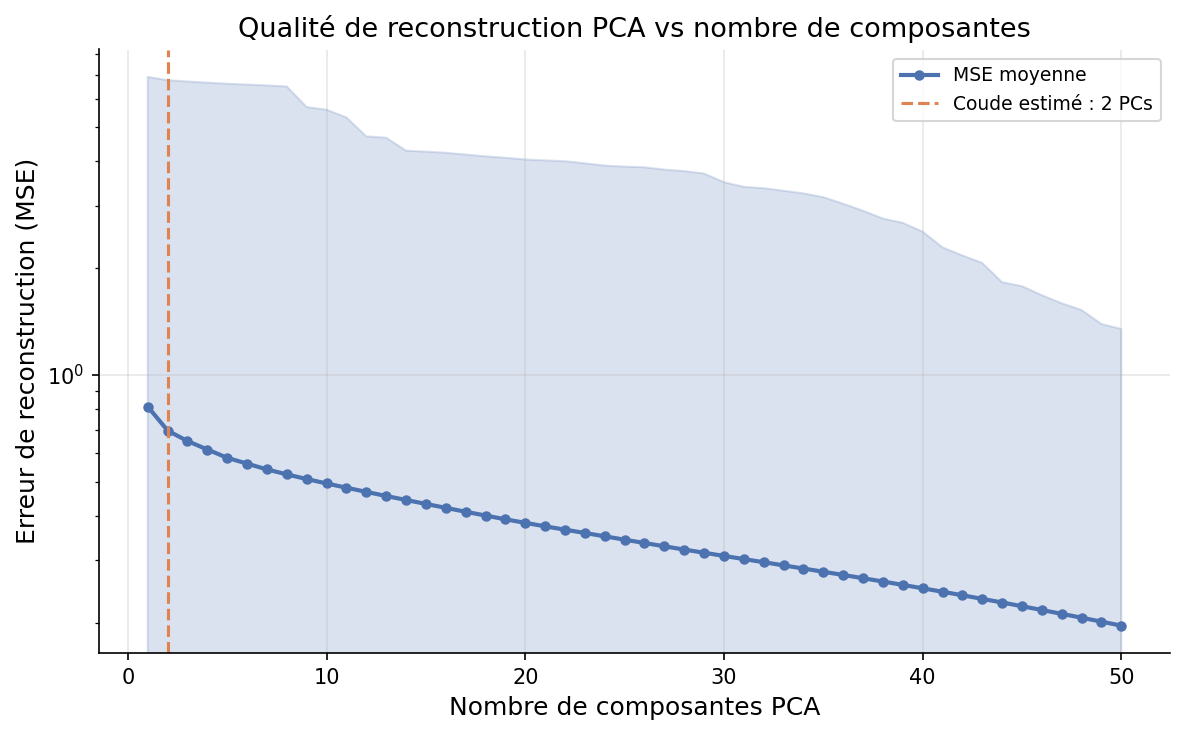

In [12]:
recon_df = pca.reconstruction_error_vs_n(
    X,
    n_range=list(range(1, 51)),
)

fig, ax = viz.plot_reconstruction_error(
    recon_df,
    save_path=FIGURES_DIR / "pca_reconstruction_error.png",
)
plt.show()

<a id="rawspec"></a>

<div style="background: linear-gradient(135deg, #1B4965 0%, #3C6E71 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(60,110,113,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">9 · PCA sur spectres bruts (eigen-spectres)</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #1B4965; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(27,73,101,0.10), rgba(60,110,113,0.10));
    border-left: 6px solid #1B4965;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #1B4965;">Ce que font les cellules de code suivantes</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Chargent des spectres FITS bruts, inspectent leur structure et leurs headers.</li>
  <li>Interpolent/normalisent les flux sur une grille commune pour former une matrice spectrale.</li>
  <li>Appliquent ensuite une PCA directement sur ces spectres.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Intérêt scientifique:</strong> ce bloc teste ce que la PCA apprend sans ingénierie de features, donc plus proche du signal instrumental et des raies natives.</p>
<p style="margin: 8px 0 0 0;"><strong>Point de vigilance:</strong> les artefacts instrumentaux peuvent capturer une partie importante de la variance des premières composantes.</p>
</div>

In [13]:
from dimred.data_loader import SpectralMatrixLoader
from sklearn.preprocessing import StandardScaler
from astropy.io import fits
import glob

spec_loader = SpectralMatrixLoader(
    fits_dir=Path(paths["RAW_DATA_DIR"]),
    catalog_path=CATALOG_PATH,
    n_jobs=8,
    random_state=RANDOM_STATE,
)

fits_dir = Path(paths["RAW_DATA_DIR"])
sample_files = list(fits_dir.rglob("*.fits*"))[:3]
print(f"Fichiers trouvés dans RAW_DATA_DIR : {len(list(fits_dir.rglob('*.fits*')))}")

for f in sample_files:
    print(f"\n--- {f.name} ---")
    try:
        with fits.open(f) as hdul:
            print(f"  HDU list : {[h.name for h in hdul]}")
            print(f"  Data shape : {hdul[0].data.shape if hdul[0].data is not None else 'None'}")
            header = hdul[0].header
            print(f"  COEFF0 : {header.get('COEFF0', 'ABSENT')}")
            print(f"  COEFF1 : {header.get('COEFF1', 'ABSENT')}")
            if hdul[0].data is not None:
                flux = hdul[0].data[0] if hdul[0].data.ndim > 1 else hdul[0].data
                print(f"  Flux range : [{flux.min():.2f}, {flux.max():.2f}]")
                print(f"  NaN count  : {np.isnan(flux).sum()}/{len(flux)}")
    except Exception as e:
        print(f"  ERREUR : {e}")

X_spec, y_spec, meta_spec = spec_loader.load(
    n_spectra=10_000,   # Sous-ensemble pour exploration rapide
    snr_min=10,
    normalize=True,
)

print(f"Matrice spectrale : {X_spec.shape}")
print(f"Grille λ : {spec_loader.wl_grid[0]:.0f} – {spec_loader.wl_grid[-1]:.0f} Å  ({len(spec_loader.wl_grid)} pixels)")

Fichiers trouvés dans RAW_DATA_DIR : 362065

--- spec-55916-B5591606_sp01-001.fits.gz ---
  HDU list : ['Flux']
  Data shape : (5, 3909)
  COEFF0 : 3.5682
  COEFF1 : 0.0001
  Flux range : [-347.64, 1647.06]
  NaN count  : 0/3909

--- spec-55916-B5591606_sp01-002.fits.gz ---
  HDU list : ['Flux']
  Data shape : (5, 3909)
  COEFF0 : 3.5682
  COEFF1 : 0.0001
  Flux range : [-272.17, 405.77]
  NaN count  : 0/3909

--- spec-55916-B5591606_sp01-003.fits.gz ---
  HDU list : ['Flux']
  Data shape : (5, 3909)
  COEFF0 : 3.5682
  COEFF1 : 0.0001
  Flux range : [-14.95, 1121.56]
  NaN count  : 0/3909


INFO | dimred.data_loader | Construction de l'index FITS dans C:\Users\alexb\Documents\Projets\AstroSpectro\data\raw...
INFO | dimred.data_loader | Index FITS construit : 362065 fichiers trouvés
INFO | dimred.data_loader | Chargement de 10000 spectres FITS (10000 résolus, 8 jobs)...
INFO | dimred.data_loader | Matrice spectrale prête : (10000, 3921)


Matrice spectrale : (10000, 3921)
Grille λ : 3690 – 9100 Å  (3921 pixels)


<div style="
    background: linear-gradient(135deg, rgba(60,110,113,0.10), rgba(27,73,101,0.10));
    border-left: 6px solid #3C6E71;
    border-radius: 10px;
    padding: 12px 14px;
    margin: 6px 0 10px 0;
">
<strong>Étape suivante:</strong> standardiser pixel par pixel puis ajuster une PCA sur les spectres bruts.
<br><br>
<strong>Lecture mathématique:</strong> on réapplique la logique de covariance/eigenvectors, mais dans l'espace longueur d'onde.
<br>
<strong>Ce que ça teste:</strong> combien de variance brute est expliquée rapidement, et si cette variance est surtout physique ou instrumentale.
</div>

INFO | dimred.pca_analyzer | PCA ajustée : 100 composantes, 99.45% variance expliquée (cumulative)
INFO | dimred.pca_analyzer | 95% variance → 5 composantes (sur 100)


Variance expliquée (100 PCs) : 99.4%


INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_spectra_variance_explained.png


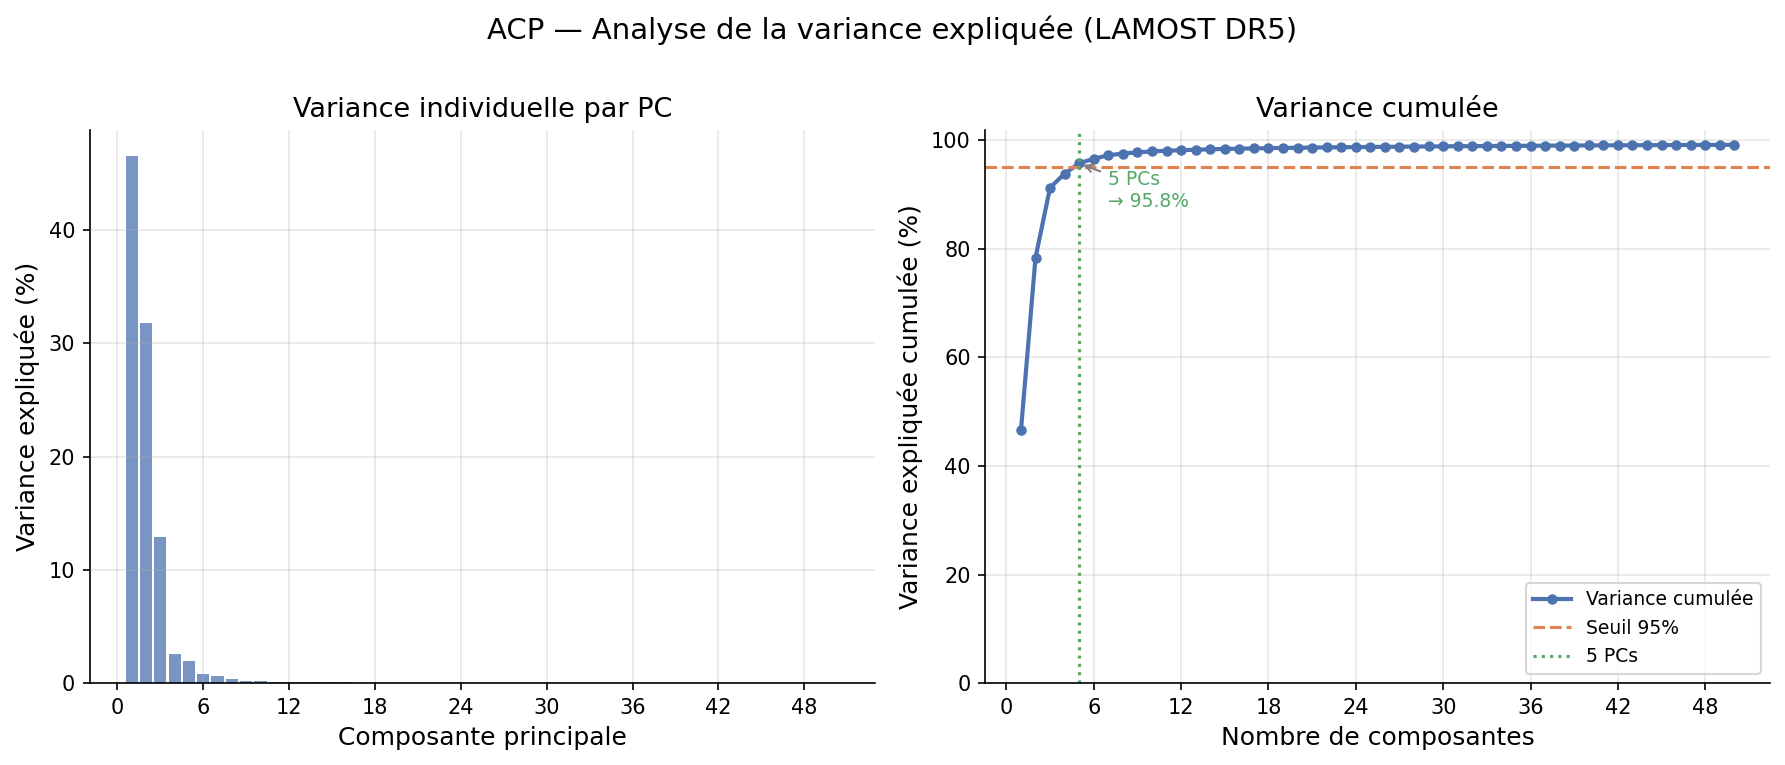

In [14]:
scaler_spec = StandardScaler()
X_spec_scaled = scaler_spec.fit_transform(X_spec)

pca_spec = PCAAnalyzer(n_components=100, random_state=RANDOM_STATE)
scores_spec = pca_spec.fit_transform(
    X_spec_scaled,
    feature_names=[f"λ{wl:.0f}" for wl in spec_loader.wl_grid],
)

print(f"Variance expliquée (100 PCs) : {pca_spec.cumulative_variance[-1]*100:.1f}%")

fig, axes = viz.plot_variance_explained(
    pca_spec, threshold=0.95,
    save_path=FIGURES_DIR / "pca_spectra_variance_explained.png",
)
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(27,73,101,0.10), rgba(19,64,116,0.10));
    border-left: 6px solid #1B4965;
    border-radius: 10px;
    padding: 12px 14px;
    margin: 6px 0 10px 0;
">
<strong>Pourquoi la cellule suivante est centrale:</strong> les 3 premiers eigen-spectres donnent une interprétation directe dans l'espace wavelength.
<br><br>
<strong>Lecture physique:</strong> les extrema autour des raies Balmer, Ca II, Mg b, Na D indiquent quelles signatures dominent chaque mode principal.
<br>
<strong>Lecture de signe:</strong> un loading positif/négatif sur une raie signifie une opposition de comportement entre populations projetées de part et d'autre de la composante.
</div>

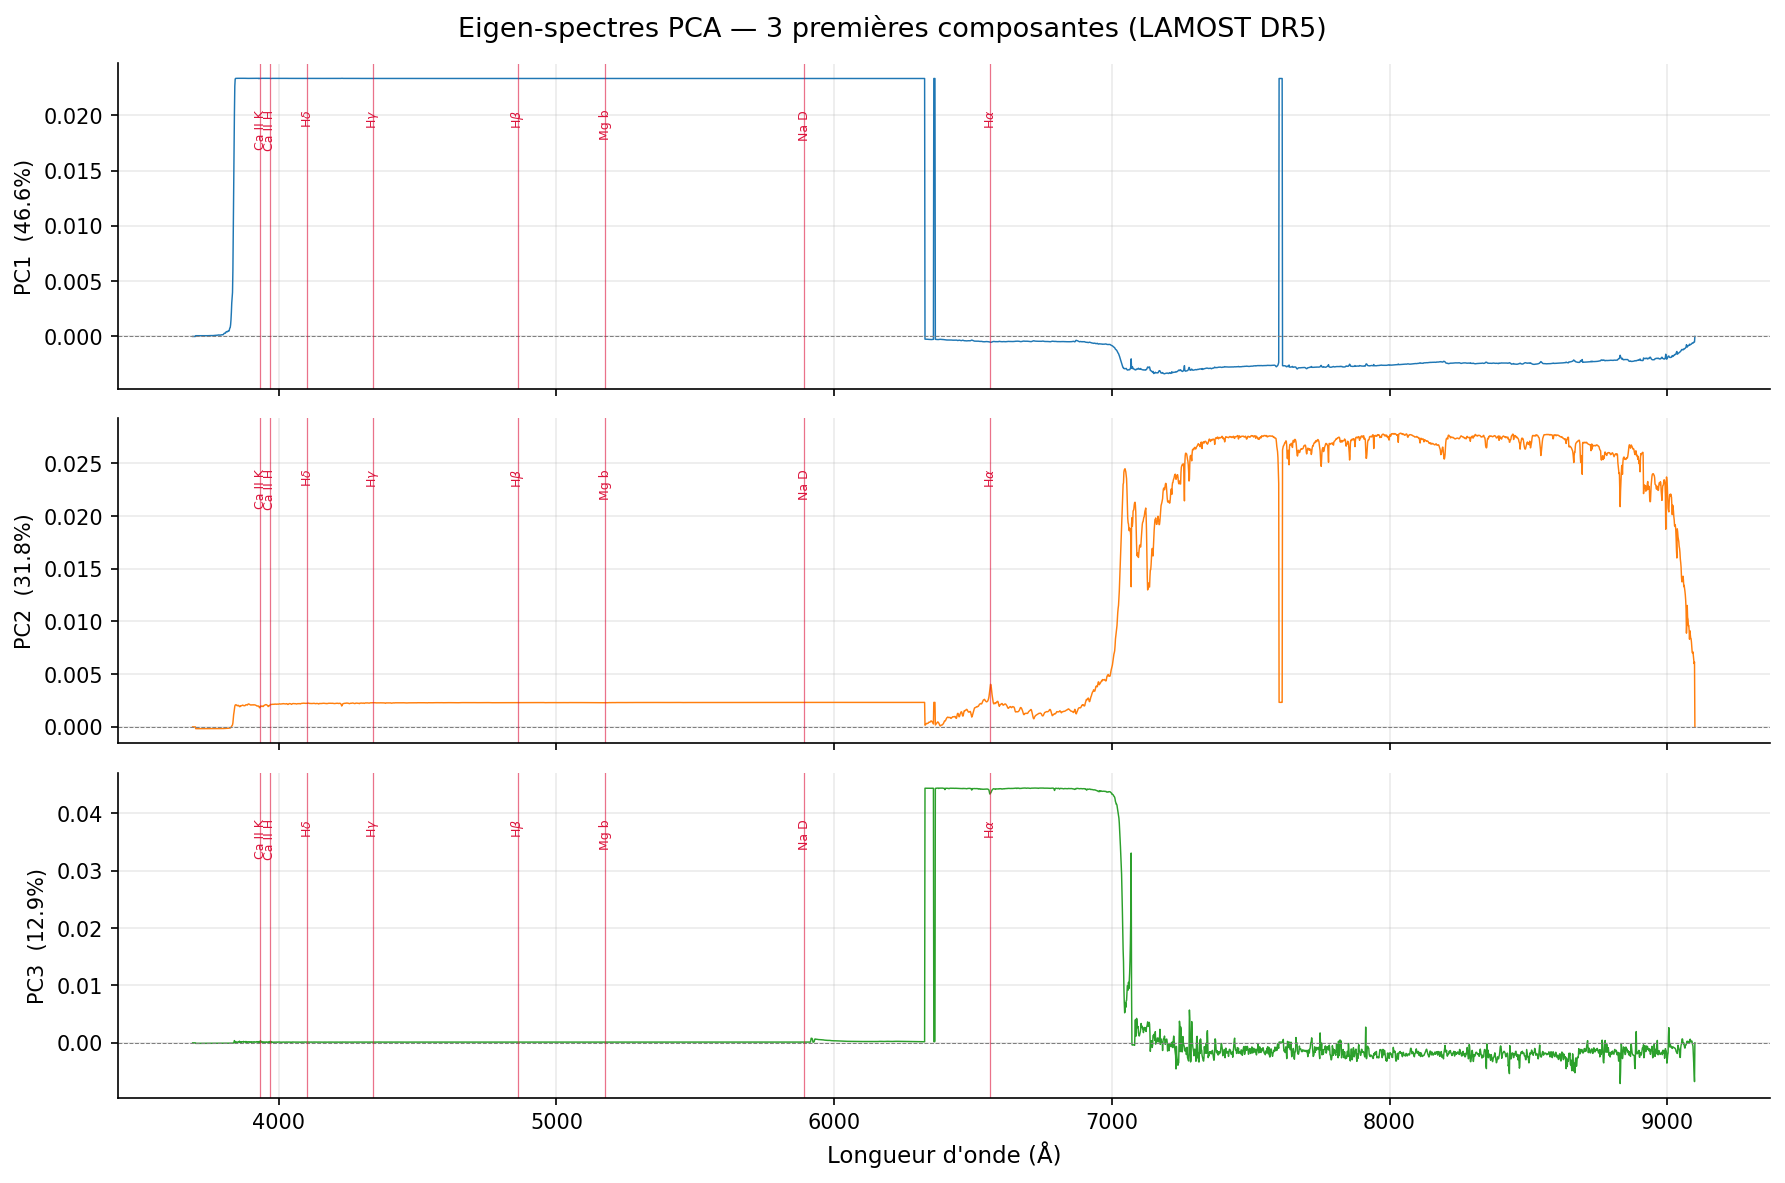

In [15]:
# Visualisation des eigen-spectres
RAIES = {
    r"H$\alpha$": 6563, r"H$\beta$": 4861, r"H$\gamma$": 4340, r"H$\delta$": 4102,
    "Ca II K": 3933, "Ca II H": 3968, "Mg b": 5175, "Na D": 5893,
}

fig, axes = plt.subplots(3, 1, figsize=(12, 8), dpi=150, sharex=True)
wl = spec_loader.wl_grid

for i, ax in enumerate(axes):
    vec = pca_spec.loadings[i]
    var_pct = pca_spec.explained_variance_ratio[i] * 100
    ax.plot(wl, vec, lw=0.7, color=f"C{i}")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_ylabel(f"PC{i+1}  ({var_pct:.1f}%)", fontsize=10)
    ax.grid(True, alpha=0.25)
    ymax = np.abs(vec).max()
    for nom, lam in RAIES.items():
        if wl.min() < lam < wl.max():
            ax.axvline(lam, color="crimson", lw=0.6, alpha=0.6)
            ax.text(lam, ymax * 0.88, nom, rotation=90, fontsize=6,
                    color="crimson", ha="center", va="top")

axes[-1].set_xlabel("Longueur d'onde (Å)", fontsize=11)
fig.suptitle("Eigen-spectres PCA — 3 premières composantes (LAMOST DR5)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pca_eigenspectra.png", bbox_inches="tight", dpi=150)
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(27,73,101,0.10), rgba(60,110,113,0.10));
    border-left: 6px solid #1B4965;
    border-radius: 10px;
    padding: 16px 18px;
    margin: 8px 0 14px 0;
">
<h4 style="margin: 0 0 10px 0; color: #1B4965;">Interprétation - Eigen-spectres et artefacts instrumentaux</h4>

<p style="margin: 0 0 8px 0;">Les premiers eigen-spectres mettent en évidence une forte sensibilité à la jonction instrumentale des bras bleu/rouge de LAMOST. Les premières composantes des spectres bruts peuvent donc capturer des signatures techniques avant la physique stellaire.</p>

<p style="margin: 0 0 8px 0;">Ce contraste avec la PCA sur features ingénierées est central: les descripteurs construits orientent l'information vers des axes interprétable physiquement.</p>

<p style="margin: 0;"><strong>Implication pipeline:</strong> pour la classification, les features ingénierées reduisent le risque d'apprentissage d'artefacts instrumentaux.</p>
</div>

<a id="hr"></a>

<div style="background: linear-gradient(135deg, #3C6E71 0%, #2A5C61 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(42,92,97,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">10 · Diagramme HR colore par coordonnée PCA</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #2A5C61; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(42,92,97,0.10), rgba(60,110,113,0.10));
    border-left: 6px solid #2A5C61;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #2A5C61;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Projette les coordonnées PCA sur le diagramme Hertzsprung-Russell.</li>
  <li>Colorie le HR par PC1 puis PC2.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Objectif:</strong> vérifier que les axes PCA suivent bien les structures évolutives stellaires connues.</p>
</div>

**Rappel astrophysique**
Le diagramme HR relie température/couleur et luminosité absolue. Avec la parallaxe Gaia (en mas), on utilise usuellement :

$$
M_G = G + 5\log_{10}(\varpi_{\mathrm{mas}}) - 10
$$

**Ce que l'on attend**
- Si PC1 encode surtout la température, le gradient de couleur PC1 doit suivre la séquence principale.
- Si PC2 encode davantage gravité/composition, son motif doit différencier des sous-populations à température comparable.

**Validation croisee**
La cohérence entre cette lecture HR et les corrélations Spearman de la section 5 est une validation physique forte de l'interprétation des composantes.

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\hr_diagram_pca_pc1.png


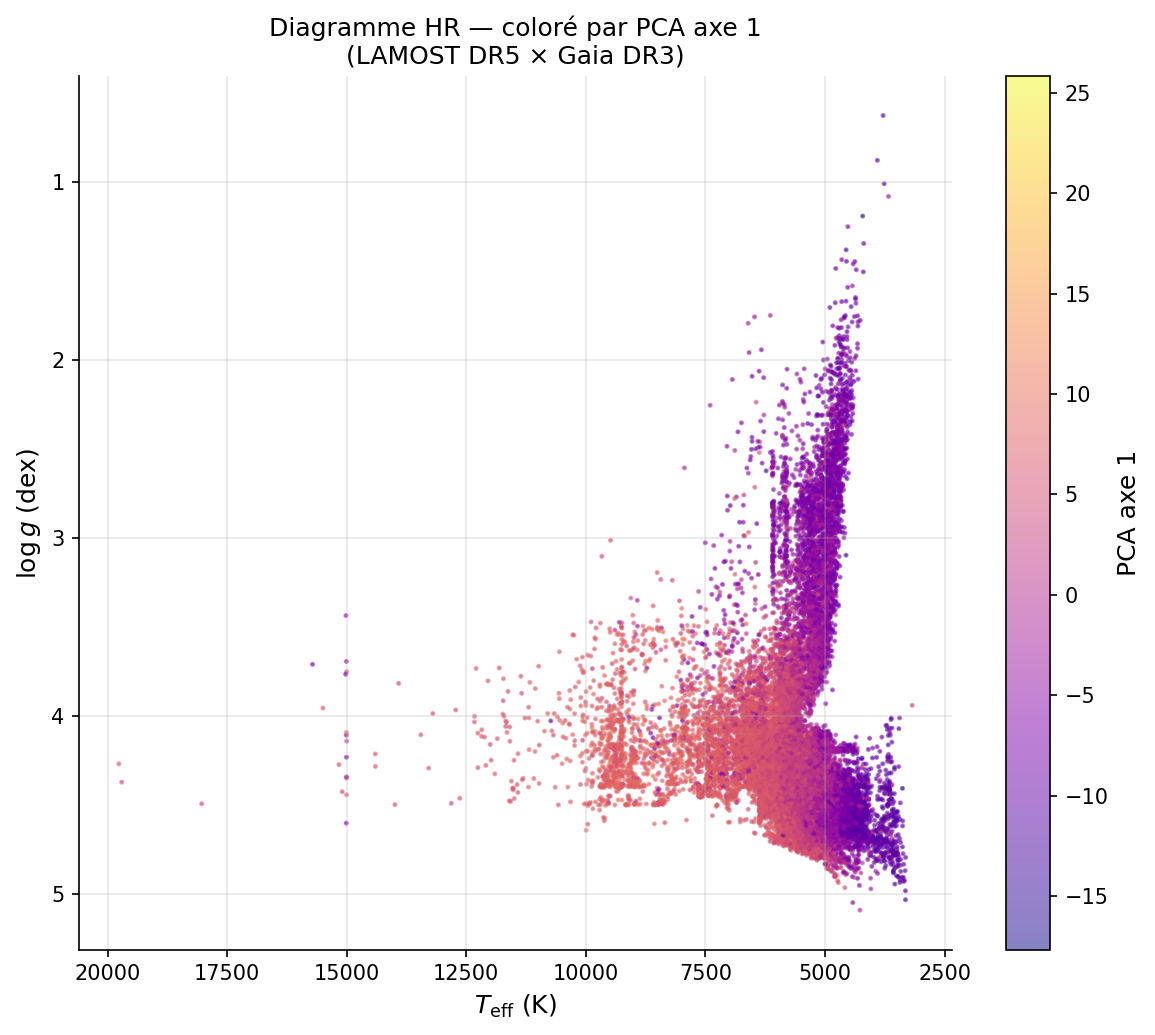

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\hr_diagram_pca_pc2.png


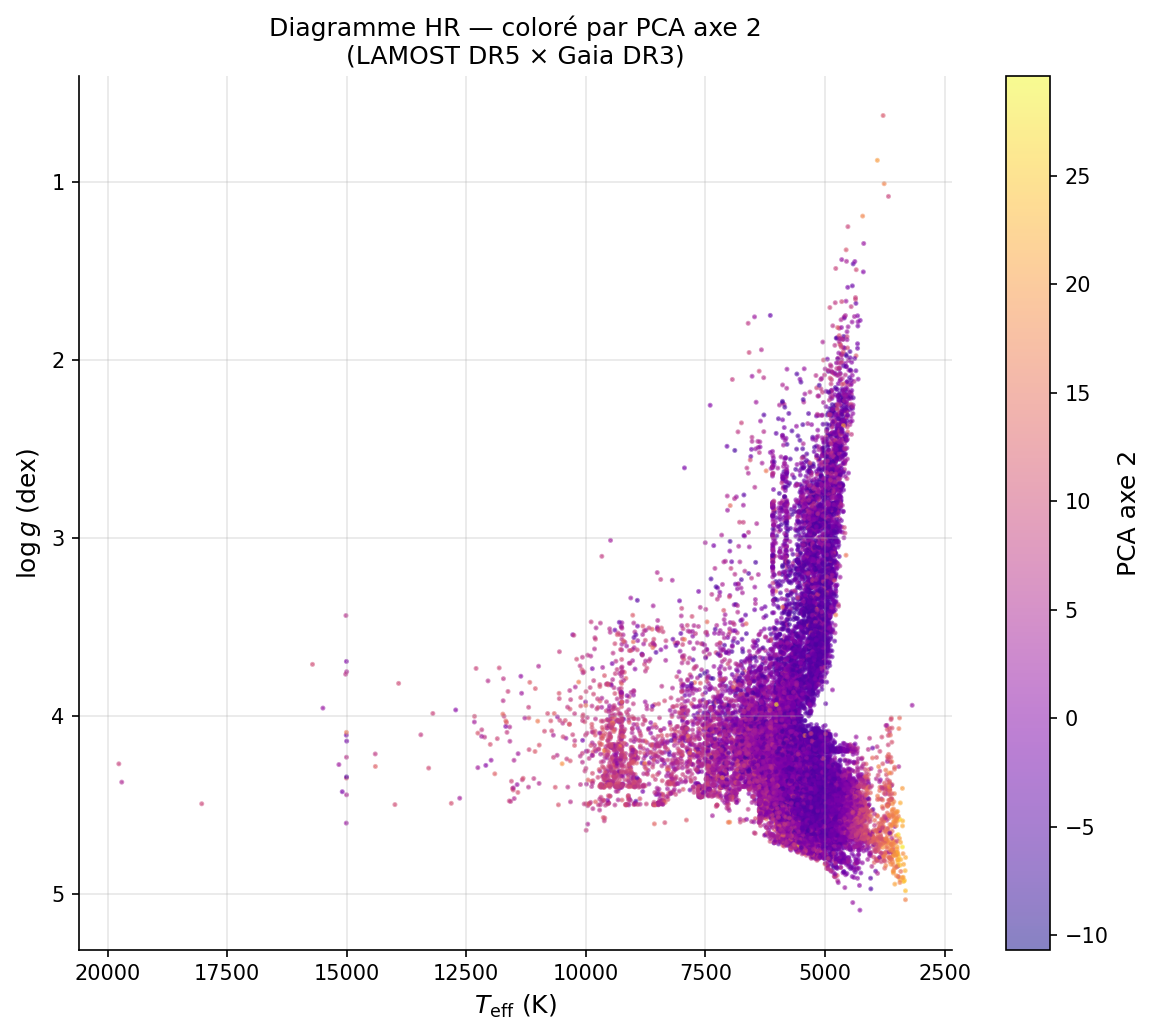

In [16]:
fig, ax = viz.plot_hr_diagram_embedding(
    meta=meta, Z=scores, component=0, method="PCA",
    save_path=FIGURES_DIR / "hr_diagram_pca_pc1.png",
)
plt.show()

fig, ax = viz.plot_hr_diagram_embedding(
    meta=meta, Z=scores, component=1, method="PCA",
    save_path=FIGURES_DIR / "hr_diagram_pca_pc2.png",
)
plt.show()

<a id="save"></a>

<div style="background: linear-gradient(135deg, #2A5C61 0%, #134074 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(19,64,116,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">11 · Sauvegarde des scores et rapports de run</h2>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #134074; text-decoration: none; font-size: 12px;">Retour a la table des matières</a>
</div>

<div style="
    background: linear-gradient(135deg, rgba(19,64,116,0.10), rgba(42,92,97,0.10));
    border-left: 6px solid #134074;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
<h4 style="margin: 0 0 8px 0; color: #134074;">Ce que fait la cellule de code qui suit</h4>
<ul style="margin: 0; padding-left: 18px; line-height: 1.55;">
  <li>Sauvegarde les sorties numériques (scores, metadonnées, résumés) en joblib.</li>
  <li>Génère un rapport JSON + TXT horodate et une version latest.</li>
  <li>Archive aussi dimensions, seuils de variance et figures produites.</li>
</ul>
<p style="margin: 10px 0 0 0;"><strong>Objectif:</strong> rendre le notebook reproductible, auditable et réutilisable dans le rapport final et les notebooks suivants.</p>
</div>

**Pourquoi cette section est methodologiquement importante**
- Le fichier joblib preserve les objets numériques (scores, classes, metadonnées) sans réexécuter tout le notebook.
- Le JSON est idéal pour la traçabilité automatique (comparaison de runs, scripts de post-analyse).
- Le TXT fournit une lecture humaine rapide pour les correcteurs.

**Bonne pratique scientifique**
Nommer explicitement les runs par horodatage (UTC) permet de relier sans ambiguïté un resultat, des figures et le contexte logiciel/données utilise.

In [17]:
import json
import joblib
from datetime import datetime, timezone


def _class_counts(labels):
    classes, counts = np.unique(labels, return_counts=True)
    return {str(cls): int(cnt) for cls, cnt in zip(classes, counts)}


def _safe_df_records(df, max_rows=None):
    if df is None:
        return None
    out = df.copy()
    if max_rows is not None:
        out = out.head(max_rows)
    out = out.where(pd.notna(out), None)
    return out.to_dict(orient="records")


def _json_default(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, datetime):
        return obj.isoformat()
    raise TypeError(f"Type non serialisable: {type(obj)!r}")


timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_dir = Path(paths["REPORTS_DIR"]) / "runs" / "phy3500_pca"
run_dir.mkdir(parents=True, exist_ok=True)

max_pcs_features = scores.shape[1]
max_pcs_spectra = scores_spec.shape[1]

n_keep = min(int(pca.n_components_for_variance(0.95)), max_pcs_features)
n_keep_spec = min(int(pca_spec.n_components_for_variance(0.95)), max_pcs_spectra)

output = {
    "scores": scores,
    "scores_95pct": scores[:, :n_keep],
    "y": y,
    "meta": meta,
    "feature_names": feature_names,
    "pca_variance_summary": pca.variance_summary(),
    "n_components_95pct": n_keep,
    "scores_spec": scores_spec,
    "scores_spec_95pct": scores_spec[:, :n_keep_spec],
    "y_spec": y_spec,
    "meta_spec": meta_spec,
    "n_keep_spec": n_keep_spec,
    "features_stem": FEATURES_PATH.stem,
}

save_path = Path(paths["REPORTS_DIR"]) / "phy3500_pca_output.joblib"
joblib.dump(output, save_path)

variance_thresholds = {
    f"{int(th * 100)}pct": min(int(pca.n_components_for_variance(th)), max_pcs_features)
    for th in (0.80, 0.90, 0.95, 0.99)
}
variance_thresholds_spec = {
    f"{int(th * 100)}pct": min(int(pca_spec.n_components_for_variance(th)), max_pcs_spectra)
    for th in (0.80, 0.90, 0.95, 0.99)
}

report = {
    "run_timestamp_utc": timestamp,
    "paths": {
        "features_path": str(FEATURES_PATH),
        "catalog_path": str(CATALOG_PATH),
        "figures_dir": str(FIGURES_DIR),
        "joblib_path": str(save_path),
        "run_dir": str(run_dir),
    },
    "shapes": {
        "X": list(X.shape),
        "scores": list(scores.shape),
        "X_spec": list(X_spec.shape),
        "scores_spec": list(scores_spec.shape),
        "scores_95pct": list(scores[:, :n_keep].shape),
        "scores_spec_95pct": list(scores_spec[:, :n_keep_spec].shape),
    },
    "class_counts": {
        "y": _class_counts(y),
        "y_spec": _class_counts(y_spec),
    },
    "pca_features": {
        "variance_explained_total_50pcs": float(pca.cumulative_variance[-1]),
        "n_components_for_variance": variance_thresholds,
        "variance_summary_top10": _safe_df_records(pca.variance_summary(), max_rows=10),
        "top_features_pc1": _safe_df_records(pca.top_features_per_pc(pc_idx=0, n_top=10)),
        "top_features_pc2": _safe_df_records(pca.top_features_per_pc(pc_idx=1, n_top=10)),
    },
    "pca_spectra": {
        "variance_explained_total_50pcs": float(pca_spec.cumulative_variance[-1]),
        "n_components_for_variance": variance_thresholds_spec,
        "variance_summary_top10": _safe_df_records(pca_spec.variance_summary(), max_rows=10),
    },
    "corrélations_pc_gaia_spearman": (
        _safe_df_records(corr_df.reset_index()) if "corr_df" in globals() else None
    ),
    "class_séparation": (
        _safe_df_records(sep_df.reset_index(drop=True)) if "sep_df" in globals() else None
    ),
    "reconstruction_error": (
        _safe_df_records(recon_df.reset_index(drop=True)) if "recon_df" in globals() else None
    ),
    "figures_saved": sorted(str(p) for p in FIGURES_DIR.glob("*.png")),
}

json_path = run_dir / f"phy3500_pca_run_{timestamp}.json"
json_latest_path = run_dir / "phy3500_pca_run_latest.json"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False, default=_json_default)

with open(json_latest_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False, default=_json_default)

text_lines = [
    "AstroSpectro | PHY-3500 PCA Run Report",
    "=" * 72,
    f"Timestamp (UTC)             : {timestamp}",
    f"Features file               : {FEATURES_PATH}",
    f"Catalog file                : {CATALOG_PATH}",
    f"Figures directory           : {FIGURES_DIR}",
    "",
    "[Saved artifacts]",
    f"- Joblib                    : {save_path}",
    f"- JSON run report           : {json_path}",
    "",
    "[Shapes]",
    f"- X                         : {X.shape}",
    f"- Scores                    : {scores.shape}",
    f"- X_spec                    : {X_spec.shape}",
    f"- Scores_spec               : {scores_spec.shape}",
    f"- Scores (95% var)          : {scores[:, :n_keep].shape} ({n_keep} PCs)",
    f"- Scores_spec (95% var)     : {scores_spec[:, :n_keep_spec].shape} ({n_keep_spec} PCs)",
    "",
    "[Class counts]",
    f"- y                         : {_class_counts(y)}",
    f"- y_spec                    : {_class_counts(y_spec)}",
    "",
    "[PCA features]",
    f"- Variance explained (50)   : {pca.cumulative_variance[-1] * 100:.2f}%",
    f"- Components for variance   : {variance_thresholds}",
    "",
    "Variance summary (top 10):",
    pca.variance_summary().head(10).to_string(index=False),
    "",
    "Top features PC1:",
    pca.top_features_per_pc(pc_idx=0, n_top=10).to_string(index=False),
    "",
    "Top features PC2:",
    pca.top_features_per_pc(pc_idx=1, n_top=10).to_string(index=False),
    "",
    "[PCA spectra]",
    f"- Variance explained (50)   : {pca_spec.cumulative_variance[-1] * 100:.2f}%",
    f"- Components for variance   : {variance_thresholds_spec}",
    "",
]

if "corr_df" in globals():
    text_lines.extend([
        "Corrélations Spearman (PC x Gaia):",
        corr_df.round(3).to_string(),
        "",
    ])

if "sep_df" in globals():
    text_lines.extend([
        "Séparation classes (résumé):",
        sep_df.round(3).to_string(index=False),
        "",
    ])

if "recon_df" in globals():
    text_lines.extend([
        "Erreur reconstruction (10 premières lignes):",
        recon_df.head(10).round(6).to_string(index=False),
        "",
    ])

text_path = run_dir / f"phy3500_pca_run_{timestamp}.txt"
text_latest_path = run_dir / "phy3500_pca_run_latest.txt"
text_content = "\n".join(text_lines)

with open(text_path, "w", encoding="utf-8") as f:
    f.write(text_content)

with open(text_latest_path, "w", encoding="utf-8") as f:
    f.write(text_content)

print(f"Scores PCA sauvegardes -> {save_path}")
print(f"Rapport JSON run        -> {json_path}")
print(f"Rapport TXT run         -> {text_path}")
print(f"Raccourci JSON latest   -> {json_latest_path}")
print(f"Raccourci TXT latest    -> {text_latest_path}")
print(f"  Features (95% var)    : {scores[:, :n_keep].shape} ({n_keep} PCs)")
print(f"  Spectres (95% var)    : {scores_spec[:, :n_keep_spec].shape} ({n_keep_spec} PCs)")

INFO | dimred.pca_analyzer | 95% variance → 91 composantes (sur 100)
INFO | dimred.pca_analyzer | 95% variance → 5 composantes (sur 100)
INFO | dimred.pca_analyzer | 80% variance → 51 composantes (sur 100)
INFO | dimred.pca_analyzer | 90% variance → 73 composantes (sur 100)
INFO | dimred.pca_analyzer | 95% variance → 91 composantes (sur 100)
INFO | dimred.pca_analyzer | 99% variance → 101 composantes (sur 100)
INFO | dimred.pca_analyzer | 80% variance → 3 composantes (sur 100)
INFO | dimred.pca_analyzer | 90% variance → 3 composantes (sur 100)
INFO | dimred.pca_analyzer | 95% variance → 5 composantes (sur 100)
INFO | dimred.pca_analyzer | 99% variance → 36 composantes (sur 100)


Scores PCA sauvegardes -> C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\phy3500_pca_output.joblib
Rapport JSON run        -> C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\runs\phy3500_pca\phy3500_pca_run_20260406T001511Z.json
Rapport TXT run         -> C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\runs\phy3500_pca\phy3500_pca_run_20260406T001511Z.txt
Raccourci JSON latest   -> C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\runs\phy3500_pca\phy3500_pca_run_latest.json
Raccourci TXT latest    -> C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\runs\phy3500_pca\phy3500_pca_run_latest.txt
  Features (95% var)    : (43019, 91) (91 PCs)
  Spectres (95% var)    : (10000, 5) (5 PCs)


<div style="
    background: linear-gradient(135deg, #0B2545 0%, #134074 50%, #3C6E71 100%);
    padding: 18px 22px;
    border-radius: 12px;
    margin: 18px 0 12px 0;
    box-shadow: 0 8px 24px rgba(11,37,69,0.30);
">
  <h2 style="color: white; margin: 0; font-weight: 350; letter-spacing: 1px;">Résumé des résultats</h2>
</div>

In [18]:
# ── Résumé automatique NB01 ──────────────────────────────────────────────
from scipy.stats import spearmanr

n95_feat = pca.n_components_for_variance(0.95)
n95_spec = pca_spec.n_components_for_variance(0.95)

top_pc1 = pca.top_features_per_pc(pc_idx=0, n_top=3)["feature"].tolist()
top_pc2 = pca.top_features_per_pc(pc_idx=1, n_top=3)["feature"].tolist()

corr = pca.correlations_with_params(meta, scores=scores, n_pcs=2)

def _r(pc_label, col):
    try:
        return f"{corr.loc[pc_label, col]:+.3f}"
    except KeyError:
        return "N/A"

sep = "=" * 60
print(sep)
print("  RÉSUMÉ — NB01 : Analyse en Composantes Principales")
print(sep)
print(f"  Variance 95 % (features)        : {n95_feat} PCs")
print(f"  Variance 95 % (spectres bruts)  : {n95_spec} PCs")
print(f"  PC1 dominée par                 : {', '.join(top_pc1)}")
print(f"  PC2 dominée par                 : {', '.join(top_pc2)}")
print(f"  Corrélation  PC1 – T_eff        : ρ = {_r('PC1', 'teff_gspphot')}")
print(f"  Corrélation  PC1 – log g        : ρ = {_r('PC1', 'logg_gspphot')}")
print(f"  Corrélation  PC1 – [Fe/H]       : ρ = {_r('PC1', 'mh_gspphot')}")
print(f"  Corrélation  PC2 – T_eff        : ρ = {_r('PC2', 'teff_gspphot')}")
print(f"  Corrélation  PC2 – [Fe/H]       : ρ = {_r('PC2', 'mh_gspphot')}")
print(sep)
print("\n→ Notebook suivant : 02_umap_tsne.ipynb")

INFO | dimred.pca_analyzer | 95% variance → 91 composantes (sur 100)
INFO | dimred.pca_analyzer | 95% variance → 5 composantes (sur 100)


  RÉSUMÉ — NB01 : Analyse en Composantes Principales
  Variance 95 % (features)        : 91 PCs
  Variance 95 % (spectres bruts)  : 5 PCs
  PC1 dominée par                 : feature_Hα_eq_width, feature_continuum_asymmetry, feature_Mg_b_eq_width
  PC2 dominée par                 : feature_FeH_proxy, feature_metal_index_combined, feature_alpha_elements_index
  Corrélation  PC1 – T_eff        : ρ = +0.831
  Corrélation  PC1 – log g        : ρ = -0.155
  Corrélation  PC1 – [Fe/H]       : ρ = -0.548
  Corrélation  PC2 – T_eff        : ρ = +0.156
  Corrélation  PC2 – [Fe/H]       : ρ = -0.082

→ Notebook suivant : 02_umap_tsne.ipynb


<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #DCE7EF;
    border-radius: 10px;
    padding: 12px 14px;
    margin-bottom: 12px;
">
Tableau complété à partir du run <strong>20260405T211716Z</strong>
(<code>data/reports/runs/phy3500_pca/phy3500_pca_run_20260405T211716Z.json</code>).
</div>

| Analyse | Résultat clé (run 20260405T211716Z) |
|---------|--------------------------------------|
| Échantillons utilisés (features) | 43 019 objets, 183 features |
| Répartition des classes | STAR=42 956, GALAXY=56, QSO=7 |
| Variance 95% (features) | 91 PCs (sur 100 PCs évaluées) |
| Variance 95% (spectres bruts) | 5 PCs (sur 100 PCs évaluées) |
| Variance expliquée totale (features, 100 PCs) | 96.67% |
| Variance expliquée totale (spectres bruts, 100 PCs) | 99.45% |
| PC1 dominée par | Halpha_eq_width (+), continuum_asymmetry (+), Mg_b_eq_width (-), synthetic_BV (-), flux_ratio_blue_red (+) |
| PC2 dominée par | FeH_proxy (+), metal_index_combined (+), alpha_elements_index (+), metal_poor_index (-) |
| Corrélation PC1 - T_eff (Spearman) | rho = +0.831 |
| Corrélation PC1 - [Fe/H] (Spearman) | rho = -0.548 |
| Corrélation PC2 - log g (Spearman) | rho = +0.081 |

### Lecture rapide pour le rapport
- Les features ingénierées restent moins compressibles que les spectres bruts, mais la PCA capture désormais 95% de variance en 91 composantes.
- Les spectres bruts demeurent très compressibles (95% atteint en 5 composantes), ce qui confirme une forte concentration de variance dans les premiers modes.
- L'interprétation physique reste stable: PC1 suit fortement la température et la métallicité, tandis que PC2 porte des variations plus fines.

<div style="
    margin-top: 14px;
    padding: 12px 14px;
    border-left: 5px solid #1B4965;
    background: linear-gradient(135deg, rgba(27,73,101,0.10), rgba(60,110,113,0.10));
    border-radius: 8px;
">
  <strong>Notebook suivant:</strong> <a href="./phy3500_02_umap_tsne.ipynb">phy3500_02_umap_tsne.ipynb</a>
</div>

<div style="
    background: linear-gradient(135deg, #134074 0%, #3C6E71 100%);
    padding: 16px 20px;
    border-radius: 10px;
    margin: 18px 0 10px 0;
    box-shadow: 0 6px 18px rgba(19,64,116,0.25);
">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 0.8px;">Références scientifiques et techniques</h2>
</div>

### Fondements mathématiques de la PCA
1. Pearson, K. (1901). <em>On Lines and Planes of Closest Fit to Systems of Points in Space</em>. Philosophical Magazine, 2(11), 559-572. (origine géométrique de la réduction de dimension linéaire)
2. Hotelling, H. (1933). <em>Analysis of a Complex of Statistical Variables into Principal Components</em>. Journal of Educational Psychology, 24(6), 417-441. (formalisme statistique moderne de la PCA)
3. Jolliffe, I. T., & Cadima, J. (2016). <em>Principal component analysis: a review and recent developments</em>. Philosophical Transactions A, 374:20150202. (synthèse théorique et bonnes pratiques)

### Corrélation de rang et interprétation
4. Spearman, C. (1904). <em>The proof and measurement of association between two things</em>. American Journal of Psychology, 15(1), 72-101. (définition de rho de Spearman)

### Algorithmes numériques et implémentation
5. Press, W. H., Teukolsky, S. A., Vetterling, W. T., & Flannery, B. P. <em>Numerical Recipes</em>, chapitres SVD/eigendecomposition. (base numérique des implémentations de décomposition)
6. scikit-learn developers. <em>PCA documentation</em>. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html (détails pratiques de l'implémentation SVD en Python)

### Contexte astrophysique des données
7. Gaia Collaboration (2023). <em>Gaia Data Release 3: Summary of the content and survey properties</em>. Astronomy & Astrophysics, 674, A1. (paramètres astrométriques/photométriques utilisés)
8. Luo, A.-L., et al. (2019). <em>The LAMOST DR5 release</em>. (contexte instrumental et contenu spectroscopique LAMOST)

### Ressource transversale astro-statistique
9. Ivezic, Z., Connolly, A., VanderPlas, J., & Gray, A. (2014). <em>Statistics, Data Mining, and Machine Learning in Astronomy</em>. Princeton University Press. (pont entre méthodes statistiques et applications astrophysiques)

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #DCE7EF;
    border-radius: 8px;
    padding: 10px 12px;
    margin-top: 10px;
">
Ces références couvrent les briques mobilisées dans ce notebook: définition mathématique de la PCA, corrélations de rang, aspects numériques de l'implémentation et interprétation astrophysique des jeux de données Gaia/LAMOST.
</div>